In [1]:
import meshio
import os
import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt
import pandas as pd
from numpy import genfromtxt
import math
import seaborn as sns
from matplotlib.patches import Circle
from scipy.interpolate import griddata

In [2]:
splishsplash_path = 'D:/gabi/'
splishsplash_path_e = 'E:/gabi/thesis/'
local_path = 'C:/Users/gabri/Documents/thesis/SPlisHSPlasH/output/'

## Very Basic Dam Break

In [65]:
scenes_path = splishsplash_path + 'data/Scenes/'
output_path = splishsplash_path
scene = 'DamBreakModel'

In [66]:
folders = os.listdir(output_path + '/' + scene)
folders.remove('log')
print(folders)

['dfsph_inviscid_advected_velocity_for_derivative', 'dfsph_visc_forces', 'dfsph_visc_standard_005_advected_velocity_for_derivative', 'iisph_visc_standard_005', 'pcisph_visc_standard_005', 'visc_standard_005', 'inviscid with xsph 0.001', 'testing_difusion_term_alpha 1.0']


In [67]:
folder_path = output_path + '/' + scene + '/visc_standard_005/'
print(folder_path)

folders = os.listdir(folder_path)
# folders.remove('vtk_vr10_derneg_notgood')
# folders.remove('vc_05_crossneg')
# folders.remove('vr_10_crossneg')
# folders.remove('vr_10_deltav_neg')
print(folders)

D:/gabi//DamBreakModel/visc_standard_005/
['mp_01', 'mp_04', 'vc_01', 'vc_05', 'old', 'VR 1.5 - velocity', 'VR 1.0 - velocity', 'baseline', 'VR -1.5 - velocity', 'VR -1.0 - velocity', 'VR 1.0 - acceleration', 'VR -1.0 - acceleration', 'VR 1.0 - acceleration + corrected vorticity', 'vr 1.5 - visc 0.01']


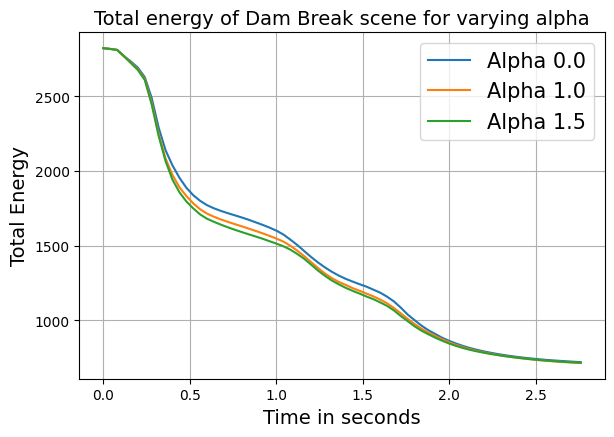

In [68]:
plt.figure(figsize=(6, 4))
begin = 1
end = 71
time = [i / 25 for i in range(70)]

dict_folders = {}
dict_folders['baseline'] = 'Alpha 0.0' 
dict_folders['VR 1.0 - acceleration + corrected vorticity'] = 'Alpha 1.0'
dict_folders['VR 1.5 - velocity'] = 'Alpha 1.5'

# for folder in folders:
for folder, label in dict_folders.items():
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
#     plt.plot(kin_energy, label="kin_energy_{}".format(folder))
    plt.plot(time, total_energy, label="{}".format(label))

plt.legend(fontsize=15)          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing
plt.title('Total energy of Dam Break scene for varying alpha', fontsize=14)
# plt.xticks(np.arange(0, 70, step=1))
plt.xlabel('Time in seconds', fontsize=14)
plt.ylabel('Total Energy', fontsize=14)
plt.savefig("basic_dambreak_energy.png", dpi=300, bbox_inches="tight")

plt.show()

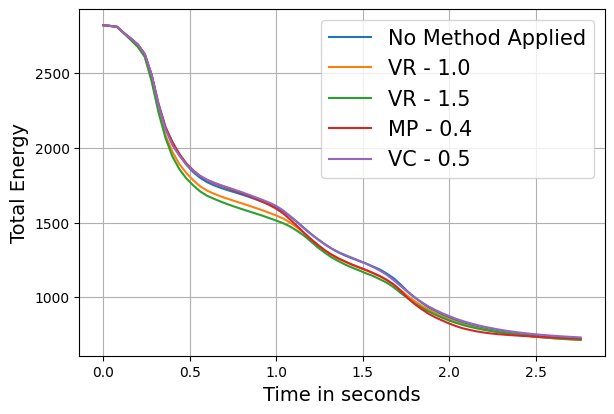

In [73]:
plt.figure(figsize=(6, 4))
begin = 1
end = 71
time = [i / 25 for i in range(70)]

dict_folders = {}
dict_folders['baseline'] = 'No Method Applied' 
dict_folders['VR 1.0 - acceleration + corrected vorticity'] = 'VR - 1.0'
dict_folders['VR 1.5 - velocity'] = 'VR - 1.5'
dict_folders['mp_04'] = 'MP - 0.4'
dict_folders['vc_05'] = 'VC - 0.5'

# for folder in folders:
for folder, label in dict_folders.items():
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
#     plt.plot(kin_energy, label="kin_energy_{}".format(folder))
    plt.plot(time, total_energy, label="{}".format(label))

plt.legend(fontsize=15)          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing
# plt.title('Total energy of Dam Break scene for varying alpha', fontsize=14)
# plt.xticks(np.arange(0, 70, step=1))
plt.xlabel('Time in seconds', fontsize=14)
# plt.xlim(0.5, 2.0)
# plt.ylim(500, 2000)
plt.ylabel('Total Energy', fontsize=14)
plt.savefig("basic_dambreak_energy_w_other_methods.png", dpi=300, bbox_inches="tight")

plt.show()

## Green Function
##### 2D: ln(||x||)/(2pi)
##### 3D: -1/(4*pi*||x||)

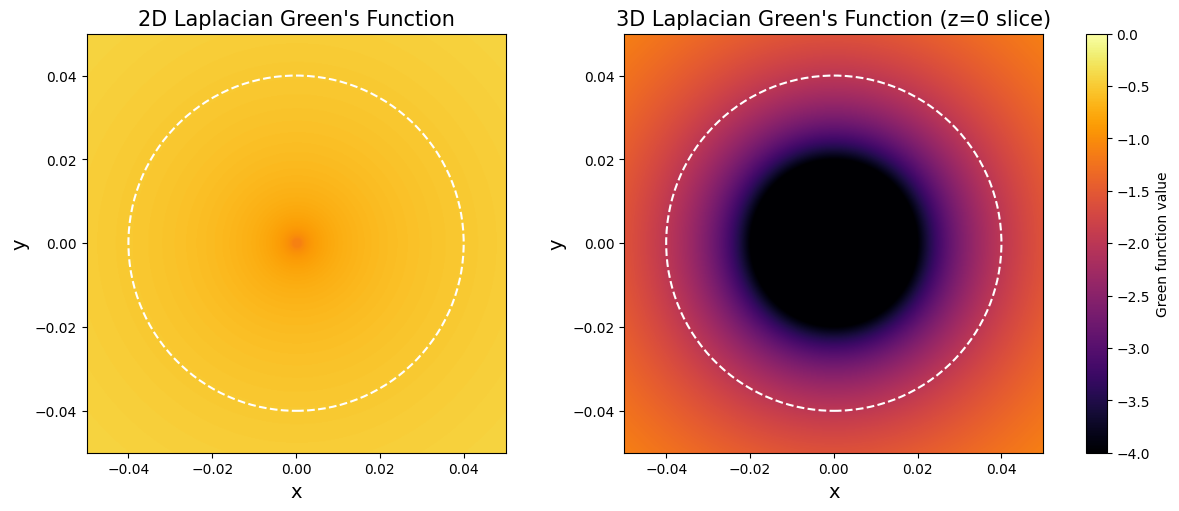

In [5]:
# Define the grid
N = 500
x = np.linspace(-0.05, 0.05, N)
y = np.linspace(-0.05, 0.05, N)
X, Y = np.meshgrid(x, y)

# Compute radius, avoid zero to prevent log(0) or division by zero
r = np.sqrt(X**2 + Y**2)
r[r < 1e-3] = 1e-3  # cutoff small radius for stability

# 2D Green's function (logarithmic)
G2D = (1/(2*np.pi)) * np.log(r)

# 3D Green's function (slice at z=0)
G3D = -(1/(4*np.pi*r))

# Define a common color scale range (e.g., -5 to 0)
vmin, vmax = -4, 0

# Clip 2D Green's function to the common scale
G2D_clipped = np.clip(G2D, vmin, vmax)

# Plotting with constrained_layout=True to avoid layout warnings
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# 2D plot with shared scale
im1 = axes[0].imshow(G2D_clipped, extent=[-0.05,0.05,-0.05,0.05], origin='lower', cmap='inferno', vmin=vmin, vmax=vmax)
axes[0].set_title("2D Laplacian Green's Function", fontsize=15)
axes[0].set_xlabel('x', fontsize=14)
axes[0].set_ylabel('y', fontsize=14)

# 3D plot with shared scale
im2 = axes[1].imshow(G3D, extent=[-0.05,0.05,-0.05,0.05], origin='lower', cmap='inferno', vmin=vmin, vmax=vmax)
axes[1].set_title("3D Laplacian Green's Function (z=0 slice)", fontsize=15)
axes[1].set_xlabel('x', fontsize=14)
axes[1].set_ylabel('y', fontsize=14)

for ax in axes:
    circle = Circle((0, 0), 0.04, color='white', fill=False, linestyle='--', linewidth=1.5)
    ax.add_patch(circle)

# Single colorbar for both plots
fig.colorbar(im2, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04, label='Green function value')

plt.savefig('greenfunction.png', dpi=300, bbox_inches="tight")

plt.show()


## Diffusion and Stretching analysis

In [9]:
scene = 'DamBreakModelWithWallMoreFluidMoreParticles'

folder_path = splishsplash_path + scene + '/visc0.02/'

print(folder_path)
folders = os.listdir(folder_path)

print(folders)

D:/gabi/DamBreakModelWithWallMoreFluidMoreParticles/visc0.02/
['vrvisc00_baseline_particle01', 'vrvisc02_baseline_particle01', 'vrvisc05_baseline_particle01', 'vrvisc00_alpha15_particle01', 'vrvisc00_alpha13_particle01', 'vrvisc00_alpha1_particle01', 'vrvisc02_alpha1_particle01', 'vrvisc05_alpha1_particle01', 'vrvisc02_alpha1_particle02', 'vrvisc02_alpha1_particle015', 'vrvisc02_baseline_particle02', 'vrvisc02_baseline_particle015', 'vrvisc01_alpha1_particle01', 'vrvisc1_alpha1_particle01', 'vrvisc02_baseline_particle025', 'vrvisc02_alpha1_particle025', 'vrvisc01_alpha0_particle01', 'vrvisc1_alpha0_particle01', 'vrvisc02_alpha1_particle01_modinit200', 'vrvisc02_alpha1_particle01_modgrad500', 'vrvisc02_alpha1_particle01_deltae5', 'vrvisc02_alpha1_particle01_deltae4', 'vrvisc02_alpha1_particle01_deltae3']


In [10]:
begin = 1
end = 125
time = [i / 25 for i in range(end - begin)] 

total_energy = {}
avg_total_energy = {}
kin_energy = {}
avg_kin_energy = {}
vorticity_dic = {}
avg_vorticity_dic = {}
max_vorticity_dic = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    ls_total_energy = []
    ls_kin_energy = []
    enstrophy = []
    
    avg_ls_total_energy = []
    avg_ls_kin_energy = []
    avg_enstrophy = []
    
    max_enstrophy = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.01 * 0.01 * 0.01

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            avg_ls_total_energy.append(np.mean(mass * h * 9.81 + (mass * norm(velocity, axis=1)**2) / 2))
            ls_total_energy.append((aux_pot_energy + aux_kin_energy))
            ls_kin_energy.append(aux_kin_energy)
            avg_ls_kin_energy.append(np.mean((mass * norm(velocity, axis=1)**2) / 2))
            
            aux_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            max_ens = np.max((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_ens)
            avg_enstrophy.append(np.mean((norm(vorticity, axis=1)**2) / 2))
            max_enstrophy.append(max_ens)
            
    total_energy[folder] = ls_total_energy
    kin_energy[folder] = ls_kin_energy
    vorticity_dic[folder] = enstrophy
    
    avg_total_energy[folder] = avg_ls_total_energy
    avg_kin_energy[folder] = avg_ls_kin_energy
    avg_vorticity_dic[folder] = avg_enstrophy
    
    max_vorticity_dic[folder] = max_enstrophy

In [21]:
total_particles = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    file = 'ParticleData_Fluid_1.vtk'.format(i)

    mesh = meshio.read(full_path + file)
    positions = mesh.points

    h = mesh.points[:,1]
    number_particles = len(h)
            
    total_particles[folder] = number_particles
  

#### Diffusion analysis

In [55]:
folders_diffusion = {} 
folders_diffusion['vrvisc00_alpha1_particle01'] = 'Alpha 1.0 - Viscosity Parameter 0.00'
folders_diffusion['vrvisc00_baseline_particle01'] = 'Alpha 0.0'
folders_diffusion['vrvisc01_alpha1_particle01'] = 'Alpha 1.0 - Viscosity Parameter 0.01'
folders_diffusion['vrvisc02_alpha1_particle01'] = 'Alpha 1.0 - Viscosity Parameter 0.02'
folders_diffusion['vrvisc05_alpha1_particle01'] = 'Alpha 1.0 - Viscosity Parameter 0.05'
folders_diffusion['vrvisc1_alpha1_particle01'] = 'Alpha 1.0 - Viscosity Parameter 0.1'

C:\Users\gabri\AppData\Local\Temp\ipykernel_13136\1926781315.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(fontsize=15)          # show the labels


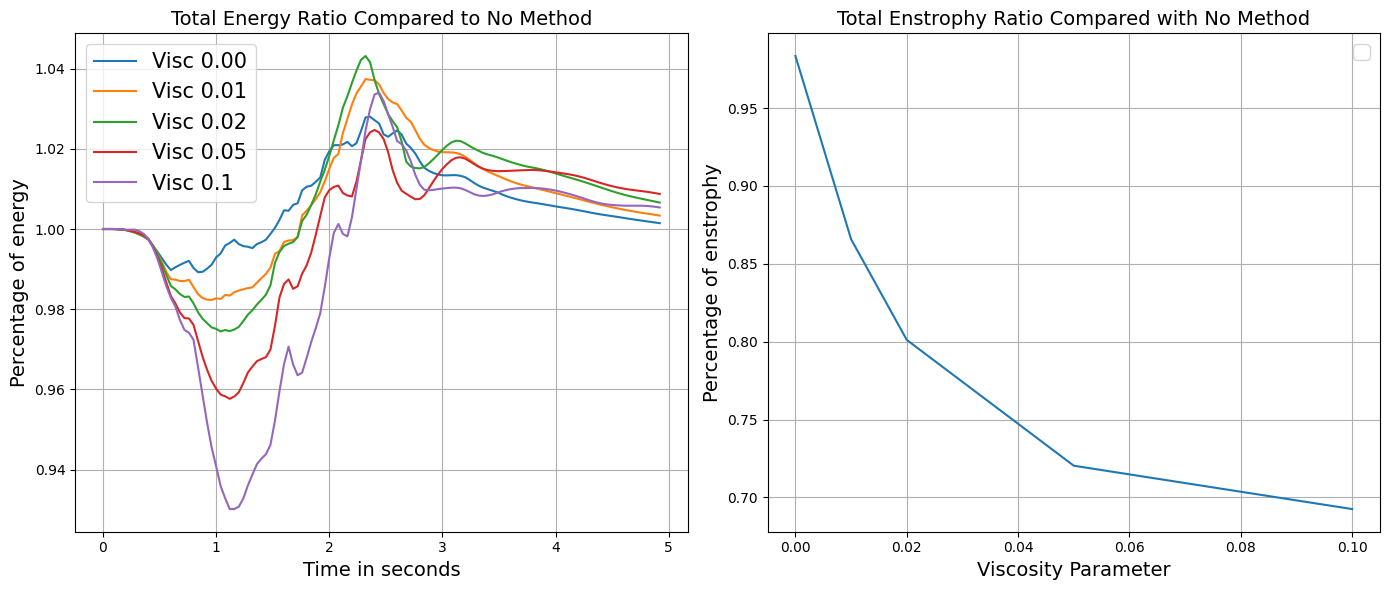

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

# vort_per_folder = []
# vort_per_folder.append(np.sum(vorticity_dic['vrvisc00_baseline_particle01']))
# vort_per_folder.append(np.sum(vorticity_dic['vrvisc00_alpha1_particle01']))
# vort_per_folder.append(np.sum(vorticity_dic['vrvisc02_alpha1_particle01']))
# vort_per_folder.append(np.sum(vorticity_dic['vrvisc05_alpha1_particle01']))

vort_rel_per_visc = []
vort_rel_per_visc.append(np.sum(vorticity_dic['vrvisc00_alpha1_particle01'])/np.sum(vorticity_dic['vrvisc00_baseline_particle01']))
vort_rel_per_visc.append(np.sum(vorticity_dic['vrvisc01_alpha1_particle01'])/np.sum(vorticity_dic['vrvisc00_baseline_particle01']))
vort_rel_per_visc.append(np.sum(vorticity_dic['vrvisc02_alpha1_particle01'])/np.sum(vorticity_dic['vrvisc00_baseline_particle01']))
vort_rel_per_visc.append(np.sum(vorticity_dic['vrvisc05_alpha1_particle01'])/np.sum(vorticity_dic['vrvisc00_baseline_particle01']))
vort_rel_per_visc.append(np.sum(vorticity_dic['vrvisc1_alpha1_particle01'])/np.sum(vorticity_dic['vrvisc00_baseline_particle01']))

ax2.plot([0.00, 0.01, 0.02, 0.05, 0.1], vort_rel_per_visc)

# for folder in folders_diffusion:
#     ax2.plot(time, max_vorticity_dic[folder], label="{}".format(folders_diffusion[folder]))    

ax2.legend(fontsize=15)          # show the labels
ax2.grid(True)        # optional grid
ax2.set_title("Total Enstrophy Ratio Compared with No Method", fontsize=14)
ax2.set_xlabel('Viscosity Parameter', fontsize=14)
ax2.set_ylabel('Percentage of enstrophy', fontsize=14)

ax1.plot(time, [x / y for x, y in zip(avg_total_energy['vrvisc00_alpha1_particle01'], avg_total_energy['vrvisc00_baseline_particle01'])], label="Visc 0.00")
ax1.plot(time, [x / y for x, y in zip(avg_total_energy['vrvisc01_alpha1_particle01'], avg_total_energy['vrvisc00_baseline_particle01'])], label="Visc 0.01")
ax1.plot(time, [x / y for x, y in zip(avg_total_energy['vrvisc02_alpha1_particle01'], avg_total_energy['vrvisc00_baseline_particle01'])], label="Visc 0.02")
ax1.plot(time, [x / y for x, y in zip(avg_total_energy['vrvisc05_alpha1_particle01'], avg_total_energy['vrvisc00_baseline_particle01'])], label="Visc 0.05")
ax1.plot(time, [x / y for x, y in zip(avg_total_energy['vrvisc1_alpha1_particle01'], avg_total_energy['vrvisc00_baseline_particle01'])], label="Visc 0.1")


ax1.legend(fontsize=15)
ax1.grid(True)
ax1.set_title("Total Energy Ratio Compared to No Method", fontsize=14)
ax1.set_xlabel('Time in seconds', fontsize=14)
ax1.set_ylabel('Percentage of energy', fontsize=14)
plt.savefig('diffusion_term_final_notebook_dambreakwwall.png', dpi=300, bbox_inches="tight")


plt.tight_layout()
plt.show()


#### Stretching Analysis

In [57]:
folders_stretching = {} 
folders_stretching['vrvisc00_alpha1_particle01'] = 'Alpha 1.0'
folders_stretching['vrvisc00_baseline_particle01'] = 'Alpha 0.0'
folders_stretching['vrvisc00_alpha13_particle01'] = 'Alpha 1.3'
folders_stretching['vrvisc00_alpha15_particle01'] = 'Alpha 1.5'

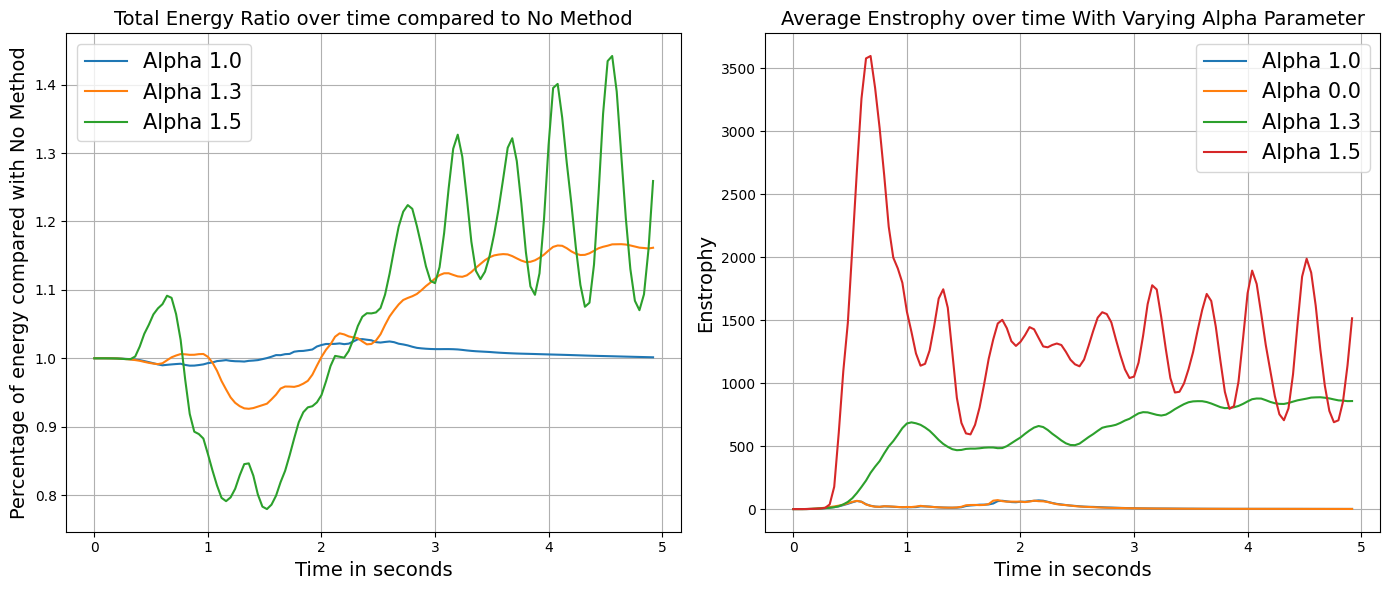

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

for folder in folders_stretching:
    ax2.plot(time, avg_vorticity_dic[folder], label="{}".format(folders_stretching[folder]))    

ax2.legend(fontsize=15)          # show the labels
ax2.grid(True)        # optional grid
ax2.set_title("Average Enstrophy over time With Varying Alpha Parameter", fontsize=14)
ax2.set_xlabel('Time in seconds', fontsize=14)
ax2.set_ylabel('Enstrophy', fontsize=14)

ax1.plot(time, [x / y for x, y in zip(avg_total_energy['vrvisc00_alpha1_particle01'], avg_total_energy['vrvisc00_baseline_particle01'])], label="Alpha 1.0")
ax1.plot(time, [x / y for x, y in zip(avg_total_energy['vrvisc00_alpha13_particle01'], avg_total_energy['vrvisc00_baseline_particle01'])], label="Alpha 1.3")
ax1.plot(time, [x / y for x, y in zip(avg_total_energy['vrvisc00_alpha15_particle01'], avg_total_energy['vrvisc00_baseline_particle01'])], label="Alpha 1.5")

ax1.legend(fontsize=15)
ax1.grid(True)
ax1.set_title("Total Energy Ratio over time compared to No Method", fontsize=14)
ax1.set_xlabel('Time in seconds', fontsize=14)
ax1.set_ylabel('Percentage of energy compared with No Method', fontsize=14)
plt.savefig('stretching_term_final_notebook_dambreakwwall.png', dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()


## Particle Size

In [22]:
print(total_particles)

{'vrvisc00_baseline_particle01': 281952, 'vrvisc02_baseline_particle01': 281952, 'vrvisc05_baseline_particle01': 281952, 'vrvisc00_alpha15_particle01': 281952, 'vrvisc00_alpha13_particle01': 281952, 'vrvisc00_alpha1_particle01': 281952, 'vrvisc02_alpha1_particle01': 281952, 'vrvisc05_alpha1_particle01': 281952, 'vrvisc02_alpha1_particle02': 31680, 'vrvisc02_alpha1_particle015': 79296, 'vrvisc02_baseline_particle02': 31680, 'vrvisc02_baseline_particle015': 79296, 'vrvisc01_alpha1_particle01': 281952, 'vrvisc1_alpha1_particle01': 281952, 'vrvisc02_baseline_particle025': 15960, 'vrvisc02_alpha1_particle025': 15960, 'vrvisc01_alpha0_particle01': 281952, 'vrvisc1_alpha0_particle01': 281952, 'vrvisc02_alpha1_particle01_modinit200': 281952, 'vrvisc02_alpha1_particle01_modgrad500': 281952}


In [23]:
folders_particles = {} 
folders_particles['vrvisc02_baseline_particle01'] = 'Alpha 0.0 Particle 0.01' 
# 281952
folders_particles['vrvisc02_alpha1_particle01'] = 'Alpha 1.0 Particle 0.01'

folders_particles['vrvisc02_baseline_particle015'] = 'Alpha 0.0 Paticle 0.015'
# 79296
folders_particles['vrvisc02_alpha1_particle015'] = 'Alpha 1.0 Paticle 0.015'

folders_particles['vrvisc02_baseline_particle02'] = 'Alpha 0.0 Particle 0.02'
# 31680
folders_particles['vrvisc02_alpha1_particle02'] = 'Alpha 1.0 Particle 0.02'

folders_particles['vrvisc02_baseline_particle025'] = 'Alpha 0.0 Particle 0.025'
# 15960
folders_particles['vrvisc02_alpha1_particle025'] = 'Alpha 1.0 Particle 0.025'


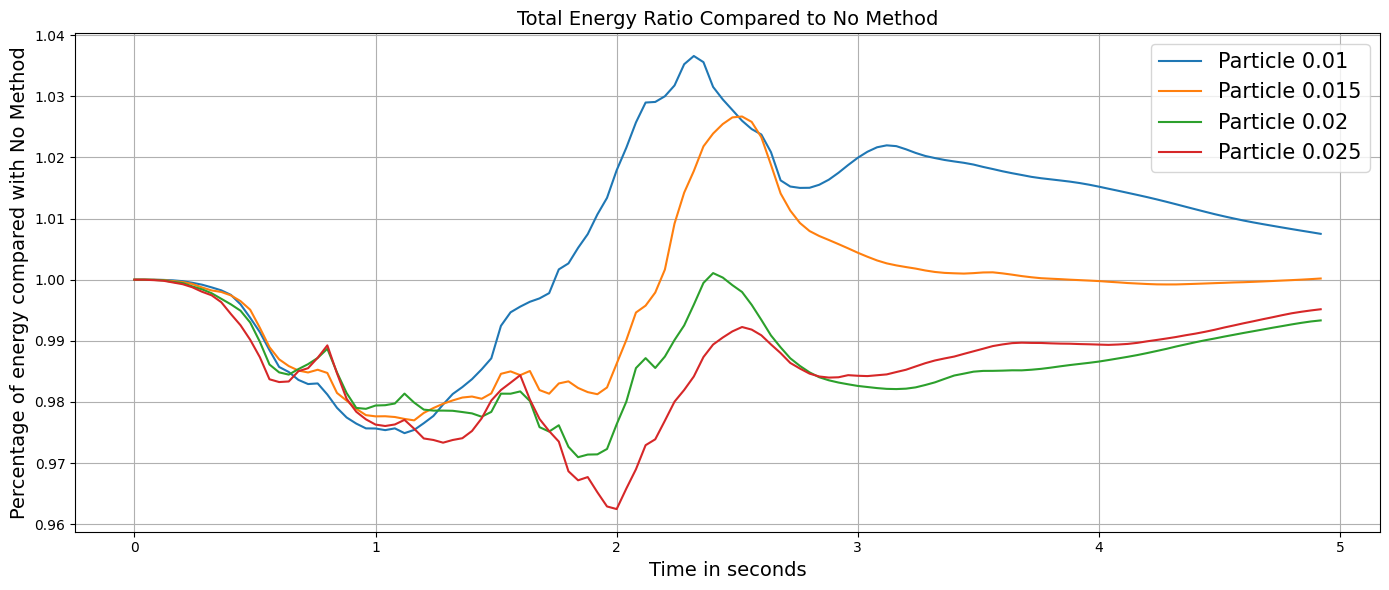

In [61]:
# rodar primeiro a parte de dam break with smaller particle antes dessa celula

fig, axes = plt.subplots(1, 1, figsize=(14, 6)) 
ax1= axes 

ax1.plot(time, [x / y for x, y in zip(avg_total_energy['vrvisc02_alpha1_particle01'], avg_total_energy['vrvisc02_baseline_particle01'])], label="Particle 0.01")
ax1.plot(time, [x / y for x, y in zip(avg_total_energy['vrvisc02_alpha1_particle015'], avg_total_energy['vrvisc02_baseline_particle015'])], label="Particle 0.015")
ax1.plot(time, [x / y for x, y in zip(avg_total_energy['vrvisc02_alpha1_particle02'], avg_total_energy['vrvisc02_baseline_particle02'])], label="Particle 0.02")
ax1.plot(time, [x / y for x, y in zip(avg_total_energy['vrvisc02_alpha1_particle025'], avg_total_energy['vrvisc02_baseline_particle025'])], label="Particle 0.025")


ax1.legend(fontsize=15)
ax1.grid(True)
ax1.set_title("Total Energy Ratio Compared to No Method", fontsize=14)
ax1.set_xlabel('Time in seconds', fontsize=14)
ax1.set_ylabel('Percentage of energy compared with No Method', fontsize=14)
plt.savefig('particle_size_dambreakwwall.png', dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()


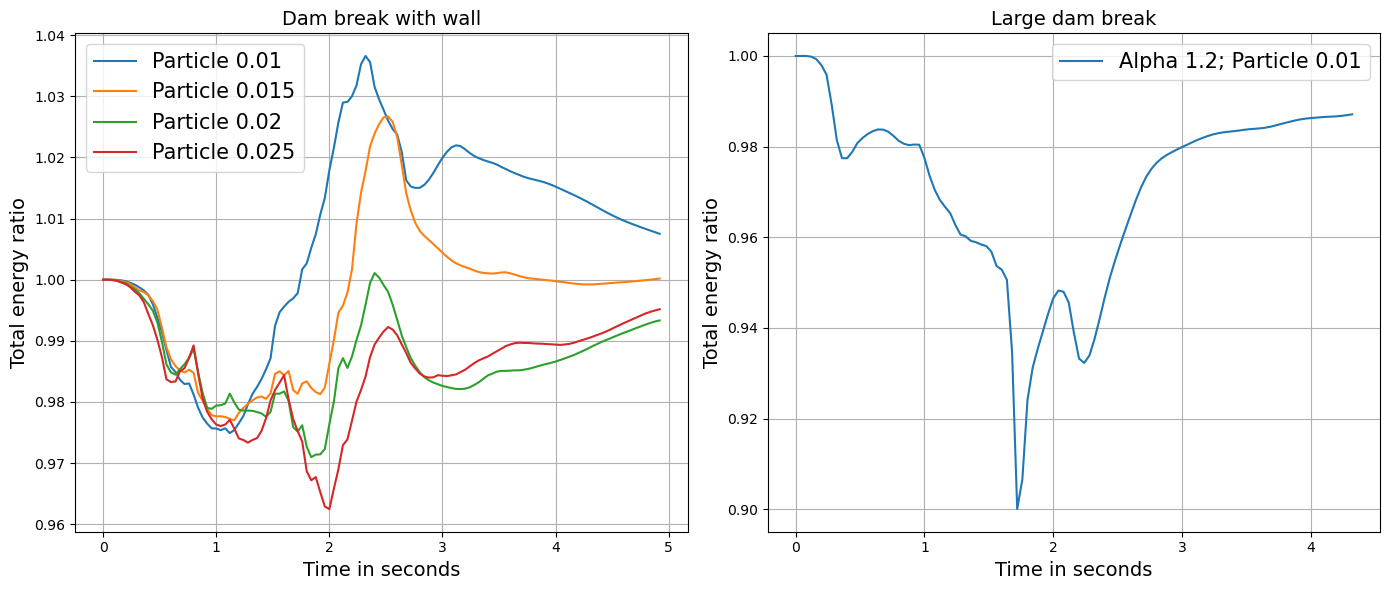

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 125
time = [i / 25 for i in range(end - begin)] 

ax1.plot(time, [x / y for x, y in zip(avg_total_energy['vrvisc02_alpha1_particle01'], avg_total_energy['vrvisc02_baseline_particle01'])], label="Particle 0.01")
ax1.plot(time, [x / y for x, y in zip(avg_total_energy['vrvisc02_alpha1_particle015'], avg_total_energy['vrvisc02_baseline_particle015'])], label="Particle 0.015")
ax1.plot(time, [x / y for x, y in zip(avg_total_energy['vrvisc02_alpha1_particle02'], avg_total_energy['vrvisc02_baseline_particle02'])], label="Particle 0.02")
ax1.plot(time, [x / y for x, y in zip(avg_total_energy['vrvisc02_alpha1_particle025'], avg_total_energy['vrvisc02_baseline_particle025'])], label="Particle 0.025")


ax1.legend(fontsize=15)
ax1.grid(True)
ax1.set_title("Dam break with wall", fontsize=14)
ax1.set_xlabel('Time in seconds', fontsize=14)
ax1.set_ylabel('Total energy ratio', fontsize=14)

begin = 1
end = 110
time = [i / 25 for i in range(end - begin)] 

ax2.plot(time, [x / y for x, y in zip(total_energy_dambreak['no cfl 0.001 alpha 1.2'], total_energy_dambreak['no cfl 0.001 baseline'])], label="Alpha 1.2; Particle 0.01")
ax2.legend(fontsize=15)
ax2.grid(True)
ax2.set_title("Large dam break", fontsize=14)
ax2.set_xlabel('Time in seconds', fontsize=14)
ax2.set_ylabel('Total energy ratio', fontsize=14)

plt.tight_layout()

plt.savefig('particle_size_bothscenes.png', dpi=300, bbox_inches="tight")
plt.show()

## CFL - nao vai pra tese

In [32]:
scene = 'DamBreakModelWithWallMoreFluidMoreParticles'

folder_path = splishsplash_path + scene + '/visc0.05/'

print(folder_path)
folders = os.listdir(folder_path)
folders.remove('old')
# folders.remove('comparingall.blend1')
# folders.remove('old-larger_fluid_breaking_on_top')

print(folders)

D:/gabi/DamBreakModelWithWallMoreFluidMoreParticles/visc0.05/
['vrvisc05_particle01_alpha0_ts001', 'vrvisc05_particle01_alpha1_ts001', 'vrvisc05_particle01_alpha0_ts0005', 'vrvisc05_particle01_alpha1_ts0005', 'vrvisc05_particle01_alpha1_cfl', 'vrvisc05_particle01_alpha0_cfl', 'vrvisc05_particle01_alpha0_cfl2', 'vrvisc05_particle01_alpha1_cfl2']


In [33]:
begin = 1
end = 87
time = [i / 25 for i in range(end - begin)] 

total_energy = {}
avg_total_energy = {}
kin_energy = {}
avg_kin_energy = {}
vorticity_dic = {}
avg_vorticity_dic = {}
max_vorticity_dic = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    ls_total_energy = []
    ls_kin_energy = []
    enstrophy = []
    
    avg_ls_total_energy = []
    avg_ls_kin_energy = []
    avg_enstrophy = []
    
    max_enstrophy = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.01 * 0.01 * 0.01

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            avg_ls_total_energy.append(np.mean(mass * h * 9.81 + (mass * norm(velocity, axis=1)**2) / 2))
            ls_total_energy.append((aux_pot_energy + aux_kin_energy))
            ls_kin_energy.append(aux_kin_energy)
            avg_ls_kin_energy.append(np.mean((mass * norm(velocity, axis=1)**2) / 2))
            
            aux_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            max_ens = np.max((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_ens)
            avg_enstrophy.append(np.mean((norm(vorticity, axis=1)**2) / 2))
            max_enstrophy.append(max_ens)
            
    total_energy[folder] = ls_total_energy
    kin_energy[folder] = ls_kin_energy
    vorticity_dic[folder] = enstrophy
    
    avg_total_energy[folder] = avg_ls_total_energy
    avg_kin_energy[folder] = avg_ls_kin_energy
    avg_vorticity_dic[folder] = avg_enstrophy
    
    max_vorticity_dic[folder] = max_enstrophy

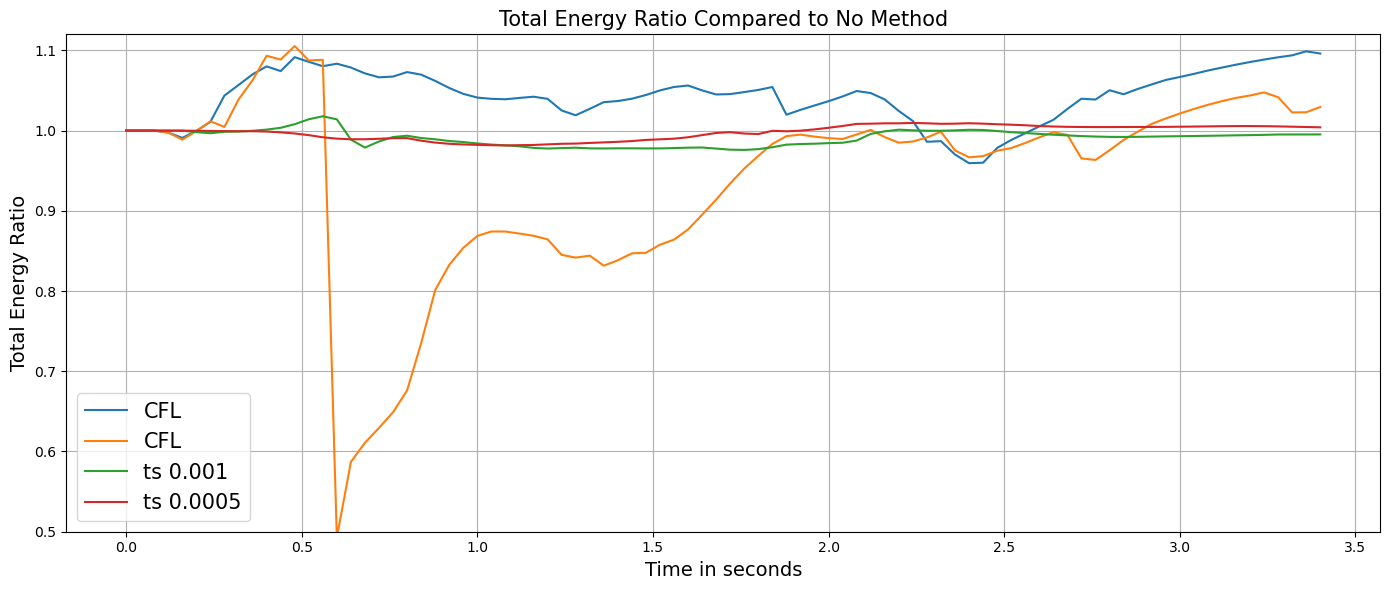

In [37]:
fig, axes = plt.subplots(1, 1, figsize=(14, 6)) 
ax1= axes 


ax1.plot(time, [x / y for x, y in zip(avg_total_energy['vrvisc05_particle01_alpha1_cfl'], avg_total_energy['vrvisc05_particle01_alpha0_cfl'])], label="CFL")
ax1.plot(time, [x / y for x, y in zip(avg_total_energy['vrvisc05_particle01_alpha1_cfl2'], avg_total_energy['vrvisc05_particle01_alpha0_cfl2'])], label="CFL")
ax1.plot(time, [x / y for x, y in zip(avg_total_energy['vrvisc05_particle01_alpha1_ts001'], avg_total_energy['vrvisc05_particle01_alpha0_ts001'])], label="ts 0.001")
ax1.plot(time, [x / y for x, y in zip(avg_total_energy['vrvisc05_particle01_alpha1_ts0005'], avg_total_energy['vrvisc05_particle01_alpha0_ts0005'])], label="ts 0.0005")

ax1.legend(fontsize=15)
ax1.grid(True)
ax1.set_title("Total Energy Ratio Compared to No Method", fontsize=15)
ax1.set_xlabel('Time in seconds', fontsize=14)
ax1.set_ylabel('Total Energy Ratio', fontsize=14)
ax1.set_ylim(0.5,1.12)

plt.tight_layout()

plt.savefig('cfl.png', dpi=300, bbox_inches="tight")
plt.show()


## Delta Velocity

In [118]:
scene = 'DamBreakModelWithWallMoreFluidMoreParticles'
folders = {}

folder_path_02 = splishsplash_path + scene + '/visc0.02/'
print(folder_path_02)
folders_02 = os.listdir(folder_path_02)
folders_02 = ['vrvisc02_alpha1_particle01']
print(folders_02)
folders[folder_path_02] = folders_02

print(folders)

D:/gabi/DamBreakModelWithWallMoreFluidMoreParticles/visc0.02/
['vrvisc02_alpha1_particle01']
{'D:/gabi/DamBreakModelWithWallMoreFluidMoreParticles/visc0.02/': ['vrvisc02_alpha1_particle01']}


In [123]:
begin = 1
end = 125
time = [i / 25 for i in range(end - begin)] 

total_del = {}
    
for path, folder in folders.items():
    full_path = path + folder[0] + '/'
    files = os.listdir(full_path)
    
    d_vel = []
    max_d_vel = []
    med_d_vel = []
    dot_vel = []
    med_dot_vel = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        delta_velocity = mesh.point_data['delta_velocity']
        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.01 * 0.01 * 0.01

        number_particles = len(h)
        if number_particles > 0:
            aux_del = np.average(norm(delta_velocity, axis=1) / norm(velocity, axis=1))
            d_vel.append(aux_del)

            aux_del = np.median(norm(delta_velocity, axis=1) / norm(velocity, axis=1))
            med_d_vel.append(aux_del)

            aux_del = np.max(norm(delta_velocity, axis=1) / norm(velocity, axis=1))
            max_d_vel.append(aux_del)

            aux_del = np.average(np.sum(delta_velocity * velocity, axis=1))
            dot_vel.append(aux_del)

            aux_del = np.median(np.sum(delta_velocity * velocity, axis=1))
            med_dot_vel.append(aux_del)
            

    # total_del[folder] = d_vel

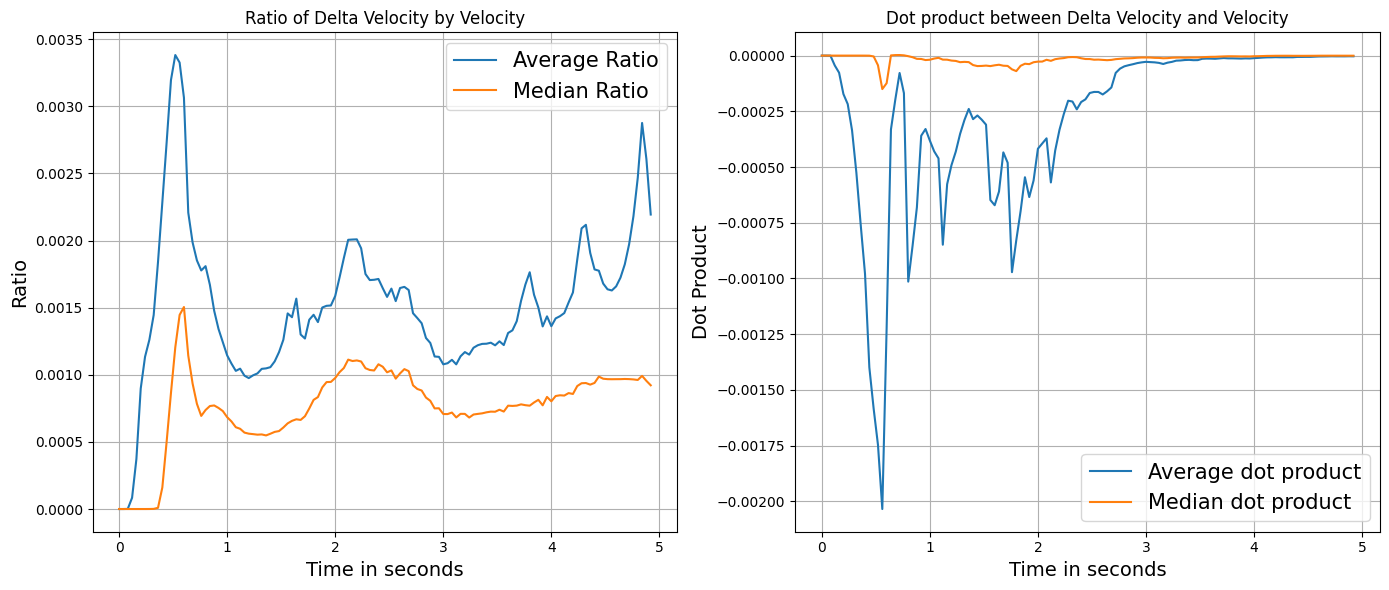

In [124]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 

ax1 = axes[0]      # first subplot
ax2 = axes[1]      # second subplot

ax1.plot(time, d_vel, label="Average Ratio")
ax1.plot(time, med_d_vel, label="Median Ratio")

ax1.legend(fontsize=15)
ax1.grid(True)
ax1.set_title("Ratio of Delta Velocity by Velocity")
ax1.set_xlabel("Time in seconds", fontsize=14)
ax1.set_ylabel("Ratio", fontsize=14)

ax2.plot(time, dot_vel, label="Average dot product")
ax2.plot(time, med_dot_vel, label="Median dot product")
ax2.legend(fontsize=15)
ax2.grid(True)
ax2.set_title("Dot product between Delta Velocity and Velocity")
ax2.set_xlabel("Time in seconds", fontsize=14)
ax2.set_ylabel("Dot Product", fontsize=14)

plt.savefig('deltaelocitydotandnorm.png', dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()


## Ideal viscosity range for method

In [ ]:
fluid inviscid visc 0.0 xsph 
fluid 0.01 visc 0.01
fluid 0.02 visc 0.02
fluid 0.05 visc 0.05

In [151]:
scene = 'DamBreakModelWithWallMoreFluidMoreParticles'
folders = {}

folder_path_05 = splishsplash_path + scene + '/visc0.05/'
print(folder_path_05)
folders_05 = os.listdir(folder_path_05)
folders_05 = ['vrvisc05_particle01_alpha0_ts001', 'vrvisc05_particle01_alpha1_ts001']
print(folders_05)
folders[folder_path_05] = folders_05

folder_path_02 = splishsplash_path + scene + '/visc0.02/'
print(folder_path_02)
folders_02 = os.listdir(folder_path_02)
folders_02 = ['vrvisc02_baseline_particle01', 'vrvisc02_alpha1_particle01']
print(folders_02)
folders[folder_path_02] = folders_02

folder_path_01 = splishsplash_path + scene + '/visc0.01/'
print(folder_path_01)
folders_01 = os.listdir(folder_path_01)
folders_01 = ['nocfl_0.001_baseline_fluid0.01_vr0.01', 'nocfl_0.001_alpha1.0_fluid0.01_vr0.01']
print(folders_01)
folders[folder_path_01] = folders_01

print(folders)

D:/gabi/DamBreakModelWithWallMoreFluidMoreParticles/visc0.05/
['vrvisc05_particle01_alpha0_ts001', 'vrvisc05_particle01_alpha1_ts001']
D:/gabi/DamBreakModelWithWallMoreFluidMoreParticles/visc0.02/
['vrvisc02_baseline_particle01', 'vrvisc02_alpha1_particle01']
D:/gabi/DamBreakModelWithWallMoreFluidMoreParticles/visc0.01/
['nocfl_0.001_baseline_fluid0.01_vr0.01', 'nocfl_0.001_alpha1.0_fluid0.01_vr0.01']
{'D:/gabi/DamBreakModelWithWallMoreFluidMoreParticles/visc0.05/': ['vrvisc05_particle01_alpha0_ts001', 'vrvisc05_particle01_alpha1_ts001'], 'D:/gabi/DamBreakModelWithWallMoreFluidMoreParticles/visc0.02/': ['vrvisc02_baseline_particle01', 'vrvisc02_alpha1_particle01'], 'D:/gabi/DamBreakModelWithWallMoreFluidMoreParticles/visc0.01/': ['nocfl_0.001_baseline_fluid0.01_vr0.01', 'nocfl_0.001_alpha1.0_fluid0.01_vr0.01']}


In [155]:
begin = 1
end = 125
time = [i / 25 for i in range(end - begin)] 

total_energy = {}
avg_total_energy = {}
kin_energy = {}
avg_kin_energy = {}
vorticity_dic = {}
avg_vorticity_dic = {}
max_vorticity_dic = {}
    
for folder_path, folders_list in folders.items():
    for folder in folders_list:
        full_path = folder_path + folder + '/'
        files = os.listdir(full_path)

        ls_total_energy = []
        ls_kin_energy = []
        enstrophy = []

        avg_ls_total_energy = []
        avg_ls_kin_energy = []
        avg_enstrophy = []

        max_enstrophy = []
        for i in range(begin,end):
            if i == 88:
                continue
            file = 'ParticleData_Fluid_{}.vtk'.format(i)

            mesh = meshio.read(full_path + file)
            positions = mesh.points

            h = mesh.points[:,1]
            velocity = mesh.point_data['velocity']
            vorticity = mesh.point_data['vorticity_corrected_end']
            mass = mesh.point_data['density'] * 0.8 * 0.01 * 0.01 * 0.01

            number_particles = len(h)
            if number_particles > 0:
                aux_pot_energy = np.sum(mass * h * 9.81)            
                aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
                avg_ls_total_energy.append(np.mean(mass * h * 9.81 + (mass * norm(velocity, axis=1)**2) / 2))
                ls_total_energy.append((aux_pot_energy + aux_kin_energy))
                ls_kin_energy.append(aux_kin_energy)
                avg_ls_kin_energy.append(np.mean((mass * norm(velocity, axis=1)**2) / 2))

                aux_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
                max_ens = np.max((norm(vorticity, axis=1)**2) / 2)
                enstrophy.append(aux_ens)
                avg_enstrophy.append(np.mean((norm(vorticity, axis=1)**2) / 2))
                max_enstrophy.append(max_ens)

        total_energy[folder] = ls_total_energy
        kin_energy[folder] = ls_kin_energy
        vorticity_dic[folder] = enstrophy

        avg_total_energy[folder] = avg_ls_total_energy
    avg_kin_energy[folder] = avg_ls_kin_energy
    avg_vorticity_dic[folder] = avg_enstrophy
    
    max_vorticity_dic[folder] = max_enstrophy

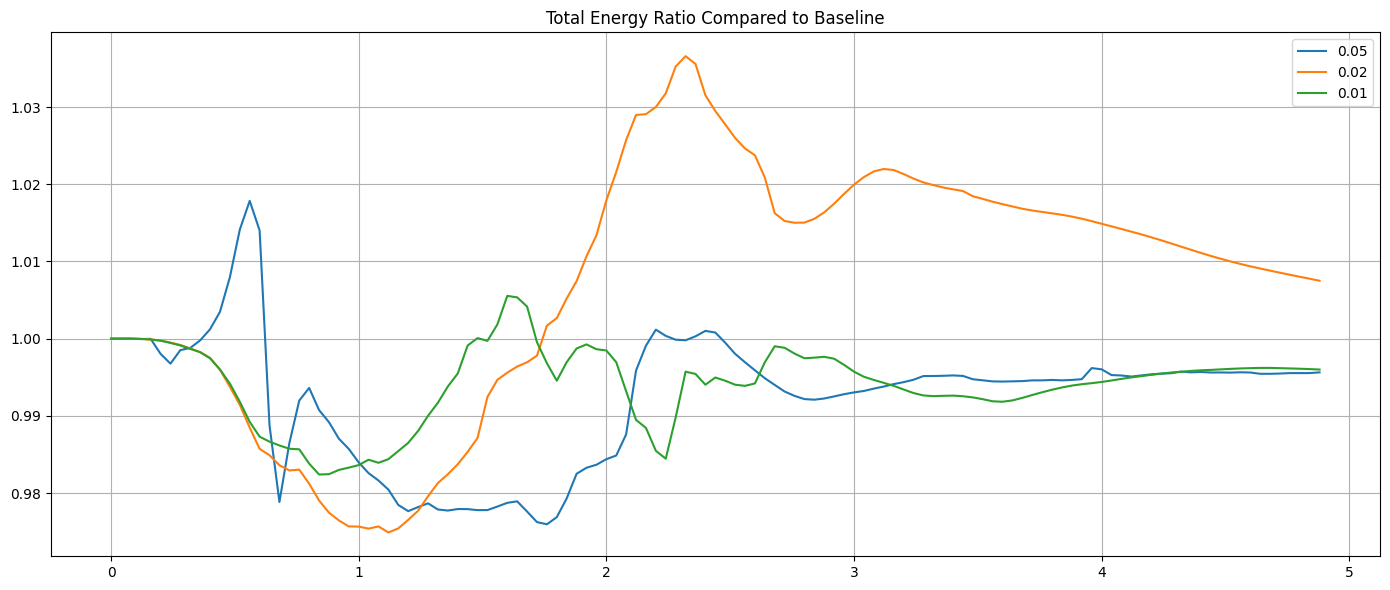

In [158]:
fig, axes = plt.subplots(1, 1, figsize=(14, 6)) 
ax1= axes 


ax1.plot(time[:-1], [x / y for x, y in zip(avg_total_energy['vrvisc05_particle01_alpha1_ts001'], avg_total_energy['vrvisc05_particle01_alpha0_ts001'])], label="0.05")
ax1.plot(time[:-1], [x / y for x, y in zip(avg_total_energy['vrvisc02_alpha1_particle01'], avg_total_energy['vrvisc02_baseline_particle01'])], label="0.02")
ax1.plot(time[:-1], [x / y for x, y in zip(avg_total_energy['nocfl_0.001_alpha1.0_fluid0.01_vr0.01'], avg_total_energy[ 'nocfl_0.001_baseline_fluid0.01_vr0.01'])], label="0.01")

ax1.legend(fontsize=10)
ax1.grid(True)
ax1.set_title("Total Energy Ratio Compared to Baseline")

plt.tight_layout()
plt.show()



## Mod Delta Velocity

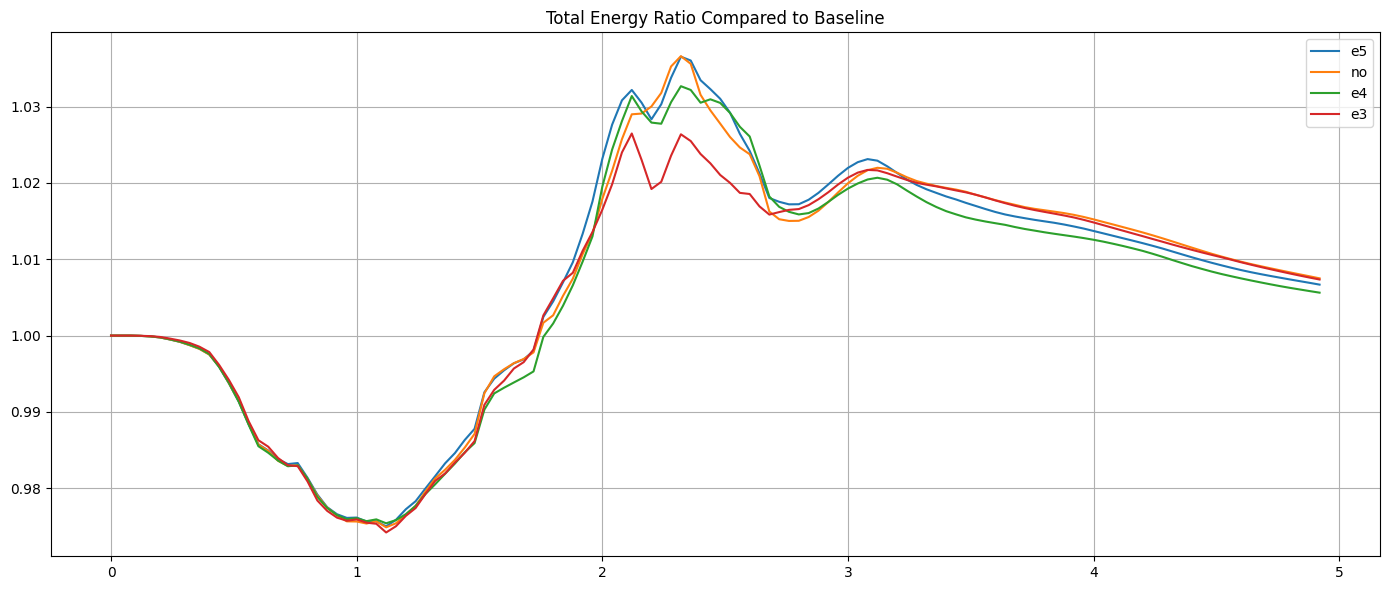

In [21]:
scene = 'DamBreakModelWithWallMoreFluidMoreParticles'

fig, axes = plt.subplots(1, 1, figsize=(14, 6)) 
ax1= axes 

begin = 1
end = 125
time = [i / 25 for i in range(end - begin)] 


ax1.plot(time, [x / y for x, y in zip(avg_total_energy['vrvisc02_alpha1_particle01_deltae5'], avg_total_energy['vrvisc02_baseline_particle01'])], label="e5")
ax1.plot(time, [x / y for x, y in zip(avg_total_energy['vrvisc02_alpha1_particle01'], avg_total_energy['vrvisc02_baseline_particle01'])], label="no")
ax1.plot(time, [x / y for x, y in zip(avg_total_energy['vrvisc02_alpha1_particle01_deltae4'], avg_total_energy[ 'vrvisc02_baseline_particle01'])], label="e4")
ax1.plot(time, [x / y for x, y in zip(avg_total_energy['vrvisc02_alpha1_particle01_deltae3'], avg_total_energy[ 'vrvisc02_baseline_particle01'])], label="e3")

ax1.legend(fontsize=10)
ax1.grid(True)
ax1.set_title("Total Energy Ratio Compared to Baseline")

plt.tight_layout()
plt.show()



In [20]:
print(len(avg_total_energy['vrvisc02_alpha1_particle01_deltae5']))
print(len(avg_total_energy['vrvisc02_baseline_particle01']))


print(len(time))

124
124
124


## Dam Break Model Smaller Particles

In [25]:
scene = 'DamBreakModelSmallerParticle'

folder_path = splishsplash_path + scene + '/visc 0.01/' 

print(folder_path)

folders = os.listdir(folder_path)
folders.remove('cfl_baseline')
folders.remove('cfl_alpha 1.2')
folders.remove('no cfl 0.001 alpha 1.0')
folders.remove('no cfl 0.005 alpha 1.2')
folders.remove('no cfl 0.005 baseline')
folders.remove('no cfl ts 0.0001 baseline')
folders.remove('no cfl ts 0.0001 alpha 1.2')
folders.remove('no cfl ts 0.0005 alpha 1.2')
folders.remove('no cfl ts 0.0005 baseline')

print(folders)

D:/gabi/DamBreakModelSmallerParticle/visc 0.01/
['no cfl 0.001 alpha 1.2', 'no cfl 0.001 baseline']


In [26]:
begin = 1
end = 110
time = [i / 25 for i in range(end - begin)]

total_energy_dambreak = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    ls_total_energy = []
    enstrophy = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.01 * 0.01 * 0.01

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            ls_total_energy.append((aux_kin_energy + aux_pot_energy))
#             ls_total_energy.append((aux_kin_energy))
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
#         else:
#             ls_total_energy.append(0)
            
    total_energy_dambreak[folder] = ls_total_energy


In [150]:
print(number_particles)

117649


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 


ax2.plot(time, [x / y for x, y in zip(total_energy['no cfl 0.001 alpha 1.2'], total_energy['no cfl 0.001 baseline'])], label="Alpha 1.2")
ax2.legend(fontsize=10)
ax2.grid(True)
ax2.set_title("Total Energy Ratio Compared to Baseline")

plt.tight_layout()
plt.show()

## Ramp and cylinder

In [4]:
scene = 'Ramp'

folder_path = splishsplash_path_e + scene + '/'

print(folder_path)

folders = os.listdir(folder_path)
folders.remove('pcisph')
folders.remove('iisph')
folders.remove('pcisph_baseline')
folders.remove('iisph_baseline')
# folders.remove('baseline_firsttry')
# folders.remove('baseline_faster')

print(folders)

E:/gabi/thesis/Ramp/
['visc02both_particle01_alpha0_cfl001', 'visc02both_particle01_alpha13_cfl001', 'Micropolar_03', 'Micropolar01', 'VC05', 'VC03']


In [5]:
begin = 1
end = 175
time = [i / 25 for i in range(end - begin)]

total_energy_ramp = {}
enstrophy_dict_ramp = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    ls_total_energy = []
    enstrophy = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            ls_total_energy.append((aux_kin_energy + aux_pot_energy))
#             ls_total_energy.append((aux_kin_energy))
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
#         else:
#             ls_total_energy.append(0)
    enstrophy_dict_ramp[folder] = enstrophy
    total_energy_ramp[folder] = ls_total_energy
#     ax1.plot(time, ls_total_energy, label="{}".format(folder))


In [47]:
scene = 'RotatingCylinder'

folder_path = splishsplash_path + scene + '/'

print(folder_path)

folders = os.listdir(folder_path)
folders.remove('baseline_firsttry')
folders.remove('baseline_faster')
folders.remove('alpha 1.0 density vr 0.01')

print(folders)

# 75 looks a good scene

D:/gabi/RotatingCylinder/
['baseline', 'alpha 1.0']


In [48]:
begin = 1
end = 204
time = [i / 25 for i in range(end - begin)]

total_energy_cylinder = {}
enstrophy_dict_cylinder = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    ls_total_energy = []
    enstrophy = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            ls_total_energy.append((aux_kin_energy + aux_pot_energy))
#             ls_total_energy.append((aux_kin_energy))
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
#         else:
#             ls_total_energy.append(0)
    enstrophy_dict_cylinder[folder] = enstrophy
    total_energy_cylinder[folder] = ls_total_energy
#     ax1.plot(time, ls_total_energy, label="{}".format(folder))


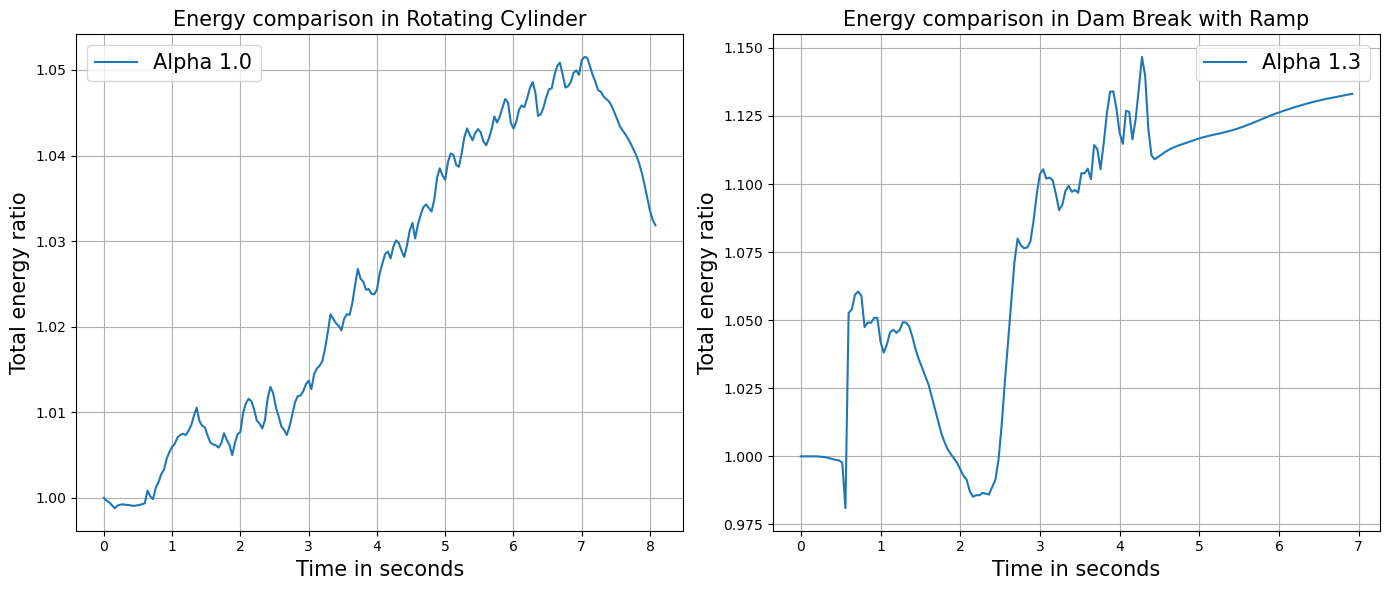

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 


ax1.plot(time, [x / y for x, y in zip(total_energy_cylinder['alpha 1.0'], total_energy_cylinder['baseline'])], label="Alpha 1.0")
ax1.legend(fontsize=15)
ax1.grid(True)
ax1.set_title("Energy comparison in Rotating Cylinder", fontsize=15)
ax1.set_xlabel("Time in seconds", fontsize=15)
ax1.set_ylabel("Total energy ratio", fontsize=15)

begin = 1
end = 175
time = [i / 25 for i in range(end - begin)]

ax2.plot(time, [x / y for x, y in zip(total_energy_ramp['visc02both_particle01_alpha13_cfl001'], total_energy_ramp['visc02both_particle01_alpha0_cfl001'])], label="Alpha 1.3")
ax2.legend(fontsize=15)
ax2.grid(True)
ax2.set_title("Energy comparison in Dam Break with Ramp", fontsize=15)
ax2.set_xlabel("Time in seconds", fontsize=15)
ax2.set_ylabel("Total energy ratio", fontsize=15)

plt.tight_layout()
plt.savefig('cylinder_ramp.png', dpi=300, bbox_inches="tight")
plt.show()


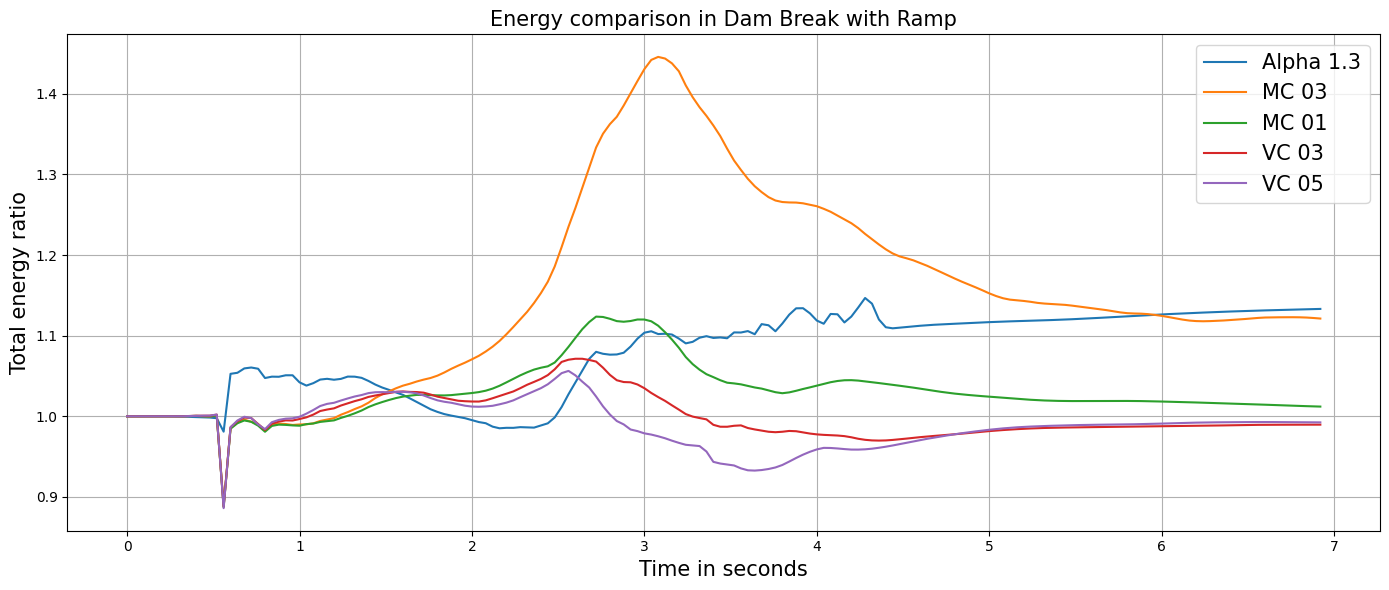

In [8]:
fig, axes = plt.subplots(1, 1, figsize=(14, 6)) 
ax2 = axes 

begin = 1
end = 175
time = [i / 25 for i in range(end - begin)]

ax2.plot(time, [x / y for x, y in zip(total_energy_ramp['visc02both_particle01_alpha13_cfl001'], total_energy_ramp['visc02both_particle01_alpha0_cfl001'])], label="Alpha 1.3")
ax2.plot(time, [x / y for x, y in zip(total_energy_ramp['Micropolar_03'], total_energy_ramp['visc02both_particle01_alpha0_cfl001'])], label="MC 03")
ax2.plot(time, [x / y for x, y in zip(total_energy_ramp['Micropolar01'], total_energy_ramp['visc02both_particle01_alpha0_cfl001'])], label="MC 01")
ax2.plot(time, [x / y for x, y in zip(total_energy_ramp['VC03'], total_energy_ramp['visc02both_particle01_alpha0_cfl001'])], label="VC 03")
ax2.plot(time, [x / y for x, y in zip(total_energy_ramp['VC05'], total_energy_ramp['visc02both_particle01_alpha0_cfl001'])], label="VC 05")

ax2.legend(fontsize=15)
ax2.grid(True)
ax2.set_title("Energy comparison in Dam Break with Ramp", fontsize=15)
ax2.set_xlabel("Time in seconds", fontsize=15)
ax2.set_ylabel("Total energy ratio", fontsize=15)

plt.tight_layout()
plt.show()


In [52]:
print(mesh)

<meshio mesh object>
  Number of points: 393984
  Number of cells:
    vertex: 393984
  Point data: id, m_is_vortex, m_lambdatwo, angular_velocity, m_vorticity_init, m_angularAcceleration, density, m_direction_vort_dev, m_direction_velocity, velocity, m_masses, mass, vorticity_advected, vorticity_corrected_end, stream, vorticity_linear_field, vorticity_derivative, vorticity_dissipation, delta_velocity, m_vorticity_equation, m_a_adv, m_velocity_from_dfsph, m_velocity_corrected_end, m_position_from_dfsph, m_vorticity_rate_laplacian, m_vorticity_rate_gradient, m_gradV_x, m_gradV_y, m_gradV_z


## Shear Flow 2D

In [10]:
scene = 'ShearFlow2D'

folder_path = splishsplash_path + scene + '/'

print(folder_path)
# folders = os.listdir(folder_path)

# folders = ['vr0.0_fluid0.03_vrvisc0_particle0.01', 'vr1.0_fluid0.03_vrvisc0_particle0.01', 'vr1.0_fluid0.03_vrvisc0.03_particle0.01']
# folders = [, , 'vr1.0_fluid0.03_vrvisc0.03_particle0.02']

folders = {}
folders['vr0.0_fluid0.03_vrvisc0_particle0.02'] = 'Baseline'
folders['vr1.0_fluid0.03_vrvisc0_particle0.02'] = 'Method Viscosity 0, Alpha 1.0'
folders['vr1.0_fluid0.03_vrvisc0.03_particle0.02'] = 'Method Viscosity 0.03, Alpha 1.0'


print(folders)
# folder = 'vr1.0_fluid0.03_vrvisc0_particle0.02'
# files = ['ParticleData_Fluid_25.vtk','ParticleData_Fluid_37.vtk', 'ParticleData_Fluid_40.vtk','ParticleData_Fluid_43.vtk','ParticleData_Fluid_50.vtk',  'ParticleData_Fluid_15.vtk']


D:/gabi/ShearFlow2D/
{'vr0.0_fluid0.03_vrvisc0_particle0.02': 'Baseline', 'vr1.0_fluid0.03_vrvisc0_particle0.02': 'Method Viscosity 0, Alpha 1.0', 'vr1.0_fluid0.03_vrvisc0.03_particle0.02': 'Method Viscosity 0.03, Alpha 1.0'}


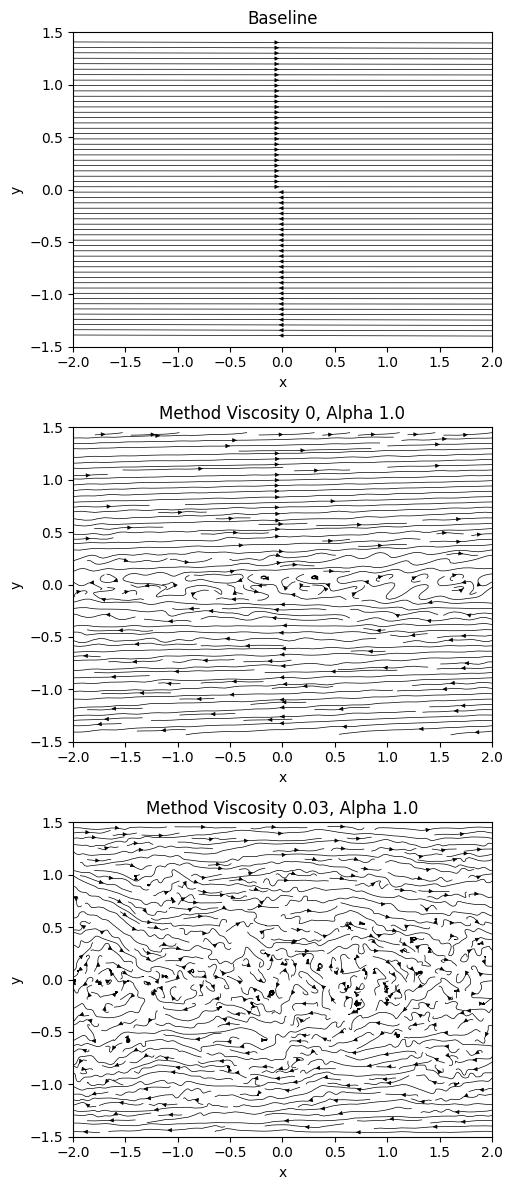

In [15]:
# --- Define the grid limits once so all plots share the same scale ---
x_min, x_max = -2, 2
y_min, y_max = -1.5, 1.5
grid_x = np.linspace(x_min, x_max, 1000)
grid_y = np.linspace(y_min, y_max, 1000)
X, Y = np.meshgrid(grid_x, grid_y)

# Create a single figure with 3 subplots stacked vertically
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 12))

for i, folder in enumerate(folders.keys()):
    full_path = folder_path + folder + '/'
    
    file = 'ParticleData_Fluid_37.vtk'
    
    mesh = meshio.read(full_path + file)
    positions = mesh.points
    velocity = mesh.point_data['velocity']
    vorticity = mesh.point_data['vorticity_corrected_end']

    x = positions[:, 0]
    y = positions[:, 1]
    vx = velocity[:, 0]
    vy = velocity[:, 1]

    # Interpolate velocities onto the fixed grid
    VX = griddata((x, y), vx, (X, Y), method='linear')
    VY = griddata((x, y), vy, (X, Y), method='linear')

    # Handle NaNs
    mask = np.isnan(VX) | np.isnan(VY)
    VX[mask] = 0
    VY[mask] = 0

    speed = np.sqrt(VX**2 + VY**2)

    ax = axes[i]
    # Adjust streamplot settings for black and white streamlines with high density
    strm = ax.streamplot(X, Y, VX, VY, color='k', linewidth=0.5, density=2.0
                         , arrowsize=0.6, minlength=0.05, maxlength=4.0)  # Increased density and black streamlines
    ax.set_title(f"{folders[folder]}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect('equal', adjustable='box')

# Adjust the layout to make space for the colorbar (if needed)
fig.subplots_adjust(right=2.0)

plt.tight_layout()
plt.show()


## ShearFlow3D

In [3]:
scene = 'ShearFlow3D'

folder_path = splishsplash_path + scene + '/'

print(folder_path)
# folders = os.listdir(folder_path)

folders = {}
folders['alpha0.0_fluid0.01_vr0.0_particle_0.02_ts_0.001'] = 'No Method'
folders['alpha1.3_fluid0.01_vr0.0_particle_0.02_ts_0.001'] = 'Method Viscosity 0.0, Alpha 1.3'
folders['alpha1.3_fluid0.01_vr0.01_particle_0.02_ts_0.001'] = 'Method Viscosity 0.01, Alpha 1.3'
# folders['alpha1.3_fluid0.01_vr0.01_particle0.02_ts_0.001_deltafiltere5'] = 'Filter e5'
# folders['alpha 1.3_fluid0.01_vr0.01_particle_0.02_ts_0.001_diff_mod_k_4_min40'] = 'Method mod k = 3'
# folders['alpha 1.3_fluid0.01_vr0.01_particle_0.02_ts_0.001_diff_mod_k_5'] = 'Method mod k = 5'


print(folders)


D:/gabi/ShearFlow3D/
{'alpha0.0_fluid0.01_vr0.0_particle_0.02_ts_0.001': 'No Method', 'alpha1.3_fluid0.01_vr0.0_particle_0.02_ts_0.001': 'Method Viscosity 0.0, Alpha 1.3', 'alpha1.3_fluid0.01_vr0.01_particle_0.02_ts_0.001': 'Method Viscosity 0.01, Alpha 1.3'}


KeyboardInterrupt: 

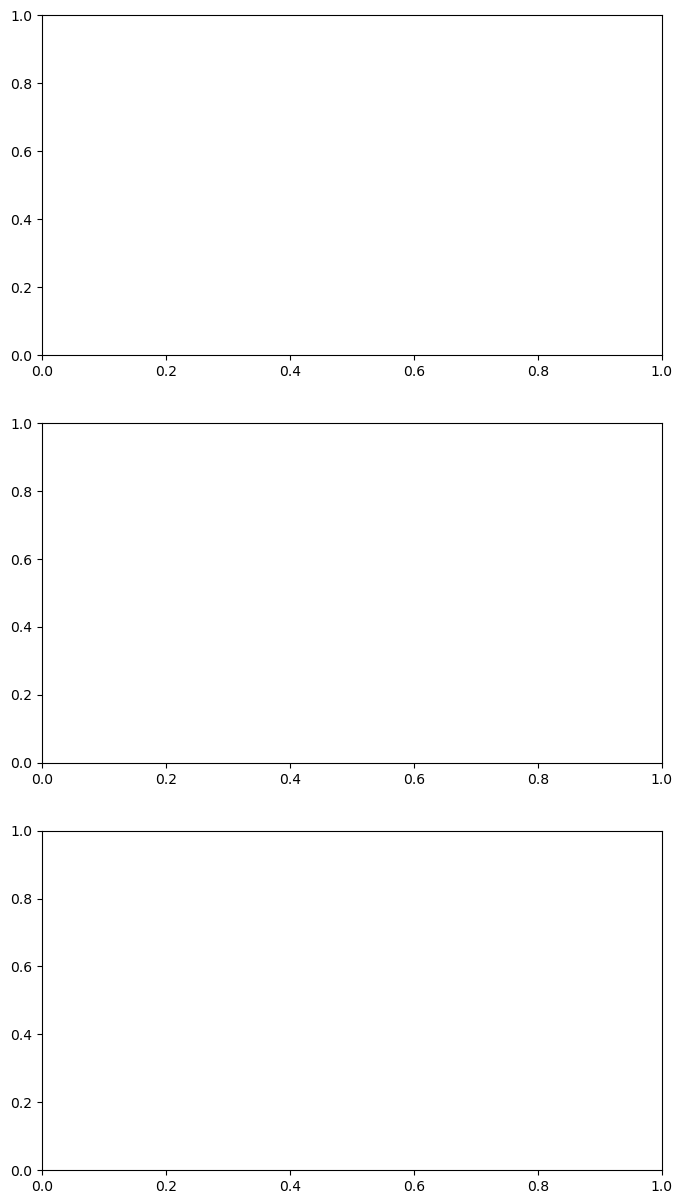

In [39]:
from matplotlib.colors import Normalize

norm_color = Normalize(vmin=0, vmax=12)


### --- Define the grid limits once so all plots share the same scale ---
x_min, x_max = -2, 2
y_min, y_max = -1.3, 1.3
grid_x = np.linspace(x_min, x_max, 1000)
grid_y = np.linspace(y_min, y_max, 1000)
X, Y = np.meshgrid(grid_x, grid_y)

# Create a single figure with 3 subplots stacked vertically
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 15))

for i, folder in enumerate(folders.keys()):
    full_path = folder_path + folder + '/'
    
    file = 'ParticleData_Fluid_25.vtk'
    
    mesh = meshio.read(full_path + file)
    positions = mesh.points
    velocity = mesh.point_data['velocity']
    vorticity = mesh.point_data['vorticity_corrected_end']
    vort = np.linalg.norm(vorticity, axis=1)

    x = positions[:, 0]
    y = positions[:, 1]
    vx = velocity[:, 0]
    vy = velocity[:, 1]

    # Interpolate velocities onto the fixed grid
    VX = griddata((x, y), vx, (X, Y), method='linear')
    VY = griddata((x, y), vy, (X, Y), method='linear')
    
    # Interpolate vorticity onto the grid
    VORT = griddata((x, y), vort, (X, Y), method='linear')

    # Handle NaNs
    mask = np.isnan(VX) | np.isnan(VY) | np.isnan(VORT)
    VX[mask] = 0
    VY[mask] = 0
    VORT[mask] = 0

    ax = axes[i]

    # --- STREAMPLOT COLORED BY VORTICITY ---
    strm = ax.streamplot(
        X, Y, VX, VY,
        color='k',
        # color=VORT,               # << color by vorticity
        # cmap='plasma',             # or 'viridis', 'plasma', etc.
        linewidth=0.5,
        density=2.0,
        arrowsize=0.6,
        norm=norm_color
    )

    # Add colorbar
    cbar = fig.colorbar(strm.lines, ax=ax)
    cbar.set_label("Vorticity Magnitude")
    
    ax.set_title(f"{folders[folder]}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect('equal', adjustable='box')

# Adjust the layout to make space for the colorbar (if needed)
fig.subplots_adjust(right=2.0)

plt.savefig('shearflow.png', dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()


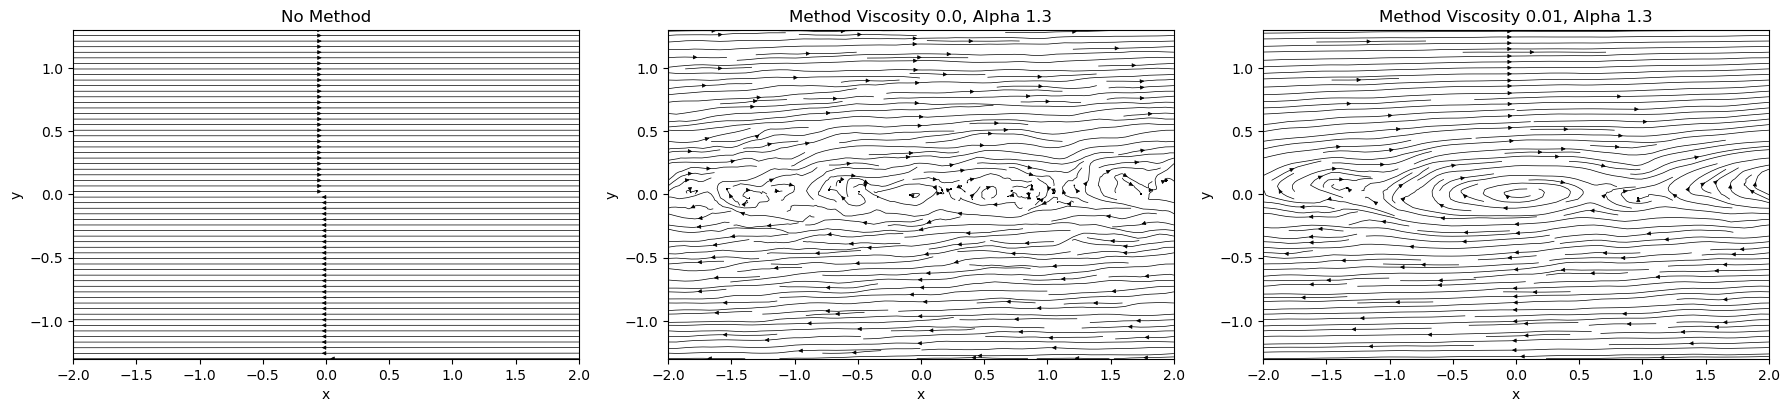

In [41]:
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata
import meshio

norm_color = Normalize(vmin=0, vmax=12)

# --- Define the grid limits once so all plots share the same scale ---
x_min, x_max = -2, 2
y_min, y_max = -1.3, 1.3
grid_x = np.linspace(x_min, x_max, 1000)
grid_y = np.linspace(y_min, y_max, 1000)
X, Y = np.meshgrid(grid_x, grid_y)

# Create a single figure with 3 subplots in a row
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))  # 1 row, 3 columns

# Loop over folders
for i, folder in enumerate(folders.keys()):
    full_path = folder_path + folder + '/'
    file = 'ParticleData_Fluid_25.vtk'
    
    mesh = meshio.read(full_path + file)
    positions = mesh.points
    velocity = mesh.point_data['velocity']
    vorticity = mesh.point_data['vorticity_corrected_end']
    vort = np.linalg.norm(vorticity, axis=1)

    x = positions[:, 0]
    y = positions[:, 1]
    vx = velocity[:, 0]
    vy = velocity[:, 1]

    # Interpolate velocities onto the fixed grid
    VX = griddata((x, y), vx, (X, Y), method='linear')
    VY = griddata((x, y), vy, (X, Y), method='linear')
    
    # Interpolate vorticity onto the grid
    VORT = griddata((x, y), vort, (X, Y), method='linear')

    # Handle NaNs
    mask = np.isnan(VX) | np.isnan(VY) | np.isnan(VORT)
    VX[mask] = 0
    VY[mask] = 0
    VORT[mask] = 0

    ax = axes[i]

    # --- STREAMPLOT COLORED BY VORTICITY ---
    strm = ax.streamplot(
        X, Y, VX, VY,
        color='k',
        # color=VORT,               
        # cmap='plasma',             
        linewidth=0.5,
        density=2.0,
        arrowsize=0.6,
        norm=norm_color
    )
    
    ax.set_title(f"{folders[folder]}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect('equal', adjustable='box')

# Add a single colorbar for all subplots
# cbar = fig.colorbar(strm.lines, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
# cbar.set_label("Vorticity Magnitude")

plt.tight_layout()
plt.savefig('shearflow2.png', dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata
import meshio
import matplotlib.gridspec as gridspec

norm_color = Normalize(vmin=0, vmax=12)

# --- Define the grid limits once so all plots share the same scale ---
x_min, x_max = -2, 2
y_min, y_max = -1.3, 1.3
grid_x = np.linspace(x_min, x_max, 1000)
grid_y = np.linspace(y_min, y_max, 1000)
X, Y = np.meshgrid(grid_x, grid_y)

# --- Create figure and GridSpec layout ---
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 2, hspace=0.3, wspace=0.2)

# Define axes explicitly
axes = [
    fig.add_subplot(gs[0, 0]),   # top-left
    fig.add_subplot(gs[0, 1]),   # top-right
    fig.add_subplot(gs[1, :])    # bottom, spanning both columns (centered)
]

# Loop over folders
for i, folder in enumerate(folders.keys()):
    full_path = folder_path + folder + '/'
    file = 'ParticleData_Fluid_25.vtk'
    
    mesh = meshio.read(full_path + file)
    positions = mesh.points
    velocity = mesh.point_data['velocity']
    vorticity = mesh.point_data['vorticity_corrected_end']
    vort = np.linalg.norm(vorticity, axis=1)

    x = positions[:, 0]
    y = positions[:, 1]
    vx = velocity[:, 0]
    vy = velocity[:, 1]

    # Interpolate velocities onto the fixed grid
    VX = griddata((x, y), vx, (X, Y), method='linear')
    VY = griddata((x, y), vy, (X, Y), method='linear')
    
    # Interpolate vorticity onto the grid
    VORT = griddata((x, y), vort, (X, Y), method='linear')

    # Handle NaNs
    mask = np.isnan(VX) | np.isnan(VY) | np.isnan(VORT)
    VX[mask] = 0
    VY[mask] = 0
    VORT[mask] = 0

    ax = axes[i]

    # --- STREAMPLOT ---
    strm = ax.streamplot(
        X, Y, VX, VY,
        color='k',
        linewidth=0.5,
        density=2.0,
        arrowsize=0.6,
        norm=norm_color
    )

    ax.set_title(f"{folders[folder]}",fontsize=15)
    ax.set_xlabel("x",fontsize=15)
    ax.set_ylabel("y",fontsize=15)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect('equal', adjustable='box')

# Optional shared colorbar (if you enable colored streamlines)
# cbar = fig.colorbar(strm.lines, ax=axes, fraction=0.03, pad=0.04)
# cbar.set_label("Vorticity Magnitude")

plt.savefig('shearflow3.png', dpi=300, bbox_inches="tight")
plt.show()


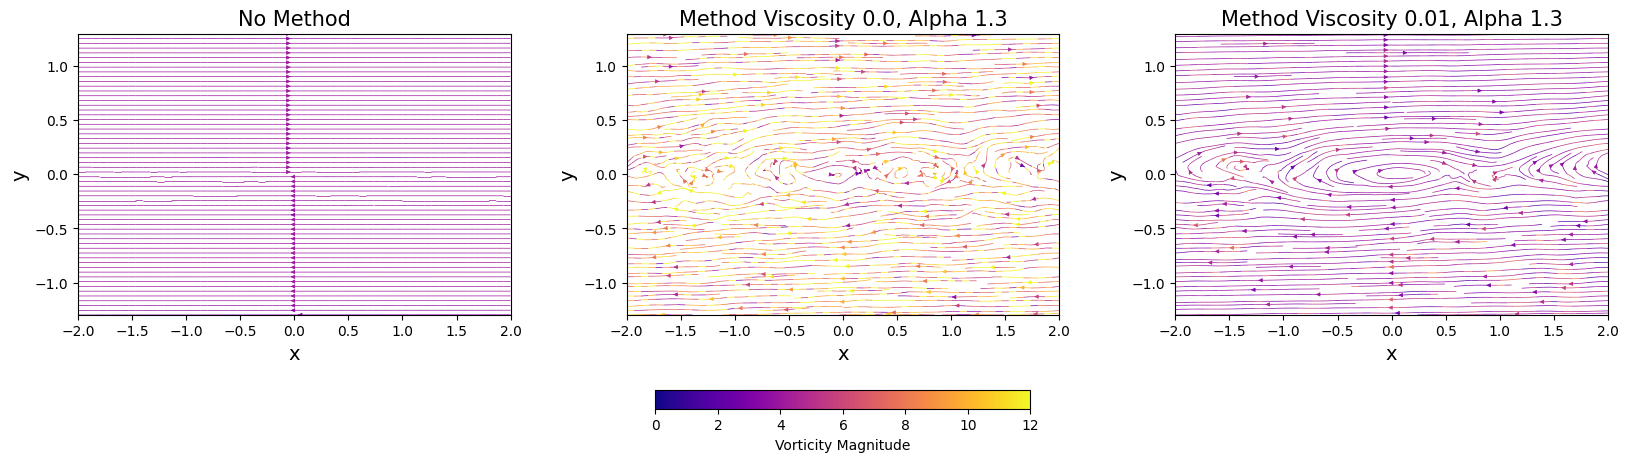

In [136]:
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata
import meshio

norm_color = Normalize(vmin=0, vmax=12)

# --- Define the grid limits once so all plots share the same scale ---
x_min, x_max = -2, 2
y_min, y_max = -1.3, 1.3
grid_x = np.linspace(x_min, x_max, 1000)
grid_y = np.linspace(y_min, y_max, 1000)
X, Y = np.meshgrid(grid_x, grid_y)

# Create a single figure with 3 subplots in a row
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))  # 1 row, 3 columns

# Loop over folders
for i, folder in enumerate(folders.keys()):
    full_path = folder_path + folder + '/'
    file = 'ParticleData_Fluid_25.vtk'
    
    mesh = meshio.read(full_path + file)
    positions = mesh.points
    velocity = mesh.point_data['velocity']
    vorticity = mesh.point_data['vorticity_corrected_end']
    vort = np.linalg.norm(vorticity, axis=1)

    x = positions[:, 0]
    y = positions[:, 1]
    vx = velocity[:, 0]
    vy = velocity[:, 1]

    # Interpolate velocities onto the fixed grid
    VX = griddata((x, y), vx, (X, Y), method='linear')
    VY = griddata((x, y), vy, (X, Y), method='linear')
    
    # Interpolate vorticity onto the grid
    VORT = griddata((x, y), vort, (X, Y), method='linear')

    # Handle NaNs
    mask = np.isnan(VX) | np.isnan(VY) | np.isnan(VORT)
    VX[mask] = 0
    VY[mask] = 0
    VORT[mask] = 0

    ax = axes[i]

    # --- STREAMPLOT COLORED BY VORTICITY ---
    strm = ax.streamplot(
        X, Y, VX, VY,
        color=VORT,               
        cmap='plasma',             
        linewidth=0.5,
        density=2.0,
        arrowsize=0.6,
        norm=norm_color
    )
    
    ax.set_title(f"{folders[folder]}", fontsize=15)
    ax.set_xlabel("x", fontsize=14)
    ax.set_ylabel("y", fontsize=14)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect('equal', adjustable='box')

# Adjust layout to make space at bottom
fig.subplots_adjust(
    left=0.02,   # reduce left margin
    right=0.97,  # reduce right margin
    top=0.95,    # reduce top margin
    bottom=0.2,  # leave enough space for the horizontal colorbar
    wspace=0.02, # reduce horizontal space between subplots
    hspace=0.05  # vertical space (not too relevant here since 1 row)
)

# Add a single horizontal colorbar below all subplots
cbar = fig.colorbar(strm.lines, ax=axes, orientation='horizontal', fraction=0.05, pad=0.2)
cbar.set_label("Vorticity Magnitude")

plt.savefig('shearflow3.png', dpi=300, bbox_inches="tight")
plt.show()


## Rotational Flow 3D - fazer de novo

In [19]:
scene = 'RotationalFlow3D'

folder_path = splishsplash_path + scene + '/'

print(folder_path)
# folders = os.listdir(folder_path)

folders = {}
folders['fluid0.01_alpha0.0_particle0.02_ts0.01_vr0.0'] = 'Baseline'
folders['fluid0.01_alpha1.3_particle0.02_ts0.001_vr0.0'] = 'Method Viscosity 0, Alpha 1.3'
folders['fluid0.01_alpha1.3_particle0.02_ts0.001_vr0.01'] = 'Method Viscosity 0.03, Alpha 1.3'


print(folders)


D:/gabi/RotationalFlow3D/
{'fluid0.01_alpha0.0_particle0.02_ts0.01_vr0.0': 'Baseline', 'fluid0.01_alpha1.3_particle0.02_ts0.001_vr0.0': 'Method Viscosity 0, Alpha 1.3', 'fluid0.01_alpha1.3_particle0.02_ts0.001_vr0.01': 'Method Viscosity 0.03, Alpha 1.3'}


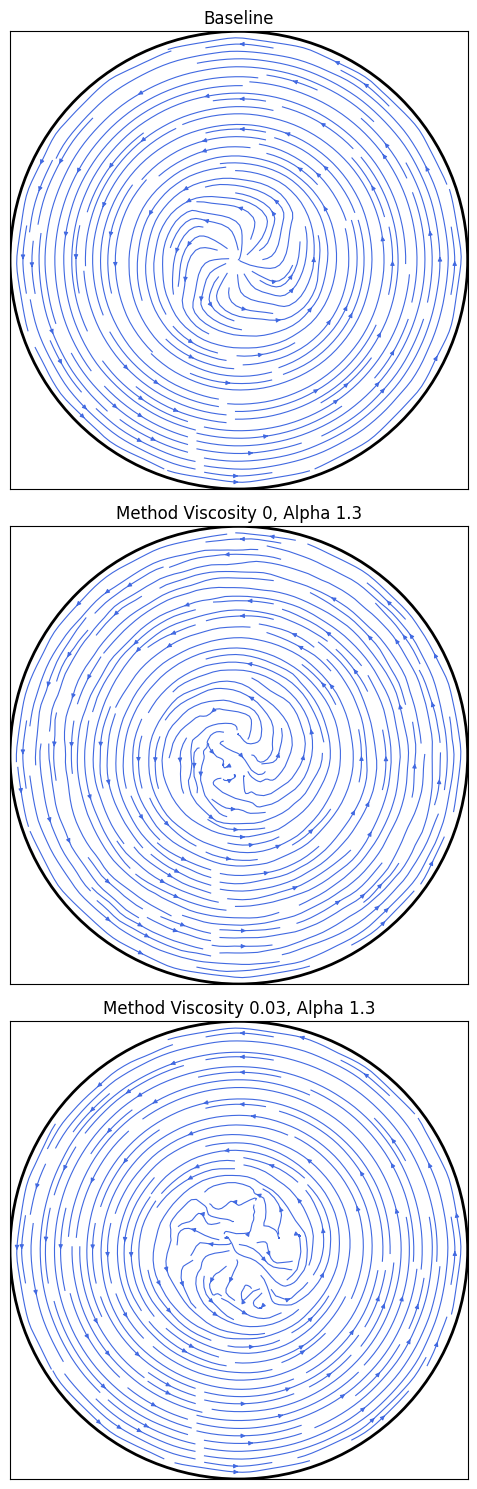

In [21]:
import numpy as np
import meshio
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from matplotlib.patches import Circle

# ----------------------------------------
# SETTINGS
# ----------------------------------------
Ngrid = 800     # grid resolution (increase for nicer streamlines)
file_name = "ParticleData_Fluid_80.vtk"

# ----------------------------------------
# Determine global circle radius from all folders
# ----------------------------------------
R_values = []

for folder in folders.keys():
    full_path = folder_path + folder + '/' + file_name
    mesh = meshio.read(full_path)
    
    x = mesh.points[:, 0]
    y = mesh.points[:, 2]
    r = np.sqrt(x**2 + y**2)
    
    R_values.append(r.max())

R = max(R_values)
R = float(np.round(R, 6))   # avoid floating-point nonuniformity
R *= 1.02

# ----------------------------------------
# Create a circular grid
# ----------------------------------------
grid = np.linspace(-R, R, Ngrid)
X, Y = np.meshgrid(grid, grid)

# Mask outside the circle
circle_mask = X**2 + Y**2 <= R**2

# ----------------------------------------
# Plot
# ----------------------------------------
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(7, 15))

for i, folder in enumerate(folders.keys()):

    # Load data
    full_path = folder_path + folder + '/' + file_name
    mesh = meshio.read(full_path)
    
    x = mesh.points[:, 0]
    y = mesh.points[:, 2]
    vx = mesh.point_data['velocity'][:, 0]
    vy = mesh.point_data['velocity'][:, 2]

    # Interpolate
    VX = griddata((x, y), vx, (X, Y), method='linear')
    VY = griddata((x, y), vy, (X, Y), method='linear')

    # Apply circle mask
    VX[~circle_mask] = np.nan
    VY[~circle_mask] = np.nan

    ax = axes[i]

    # Streamplot inside circle
    sp = ax.streamplot(
        X, Y, VX, VY,
        density=2.0,
        color='royalblue',
        linewidth=0.8,
        arrowsize=0.6
    )

    # Draw domain boundary
    circ = Circle((0, 0), R, fill=False, color='black', linewidth=2)
    ax.add_patch(circ)

    # Style
    ax.set_aspect('equal', 'box')
    ax.set_xlim(-R, R)
    ax.set_ylim(-R, R)
    ax.set_title(folders[folder])
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()


## Diss Vorticity Analysis

In [60]:
scene = 'DamBreakModelWithWallMoreFluidMoreParticles'

folder_path = splishsplash_path + scene + '/visc0.02/'

print(folder_path)

folders = os.listdir(folder_path)
# folders.remove('visc02both_particle01_alpha0_cfl001')
# folders.remove('baseline_faster')
folders = ['vrvisc02_alpha1_particle01']

print(folders)

D:/gabi/DamBreakModelWithWallMoreFluidMoreParticles/visc0.02/
['vrvisc02_alpha1_particle01']


In [63]:
begin = 1
end = 125
time = [i / 25 for i in range(end - begin)]

total_diss_ramp = {}
total_final_diss_ramp = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    ls_diss = []
    ls_final_diss = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        # print(mesh.point_data.keys())
        diss = mesh.point_data['vorticity_dissipation']
        eq = mesh.point_data['m_vorticity_equation']
        fin_vort = mesh.point_data['vorticity_corrected_end']

        number_particles = len(h)
        if number_particles > 0:
            aux_diss = np.sum(norm(diss, axis=1)**2)
            ls_diss.append(aux_diss)
            aux_diss_fin = np.sum(norm(eq - fin_vort, axis=1)**2)     
            ls_final_diss.append(aux_diss_fin)

    total_diss_ramp[folder] = ls_diss
    total_final_diss_ramp[folder] = ls_final_diss


In [70]:
scene = 'DamBreakModelSmallerParticle'

folder_path = splishsplash_path + scene + '/visc 0.01/' 

print(folder_path)

folders = os.listdir(folder_path)
folders.remove('cfl_baseline')
folders.remove('cfl_alpha 1.2')
folders.remove('no cfl 0.001 alpha 1.0')
folders.remove('no cfl 0.005 alpha 1.2')
folders.remove('no cfl 0.005 baseline')
folders.remove('no cfl ts 0.0001 baseline')
folders.remove('no cfl ts 0.0001 alpha 1.2')
folders.remove('no cfl ts 0.0005 alpha 1.2')
folders.remove('no cfl ts 0.0005 baseline')
folders.remove('no cfl 0.001 baseline')

print(folders)

D:/gabi/DamBreakModelSmallerParticle/visc 0.01/
['no cfl 0.001 alpha 1.2']


In [71]:
begin = 1
end = 125
time = [i / 25 for i in range(end - begin)]

total_diss_basicadam = {}
total_final_diss_basicadam = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    ls_diss = []
    ls_final_diss = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        # print(mesh.point_data.keys())
        diss = mesh.point_data['vorticity_dissipation']
        eq = mesh.point_data['m_vorticity_equation']
        fin_vort = mesh.point_data['vorticity_corrected_end']

        number_particles = len(h)
        if number_particles > 0:
            aux_diss = np.sum(norm(diss, axis=1)**2)
            ls_diss.append(aux_diss)
            aux_diss_fin = np.sum(norm(eq - fin_vort, axis=1)**2)     
            ls_final_diss.append(aux_diss_fin)

    total_diss_basicadam[folder] = ls_diss
    total_final_diss_basicadam[folder] = ls_final_diss


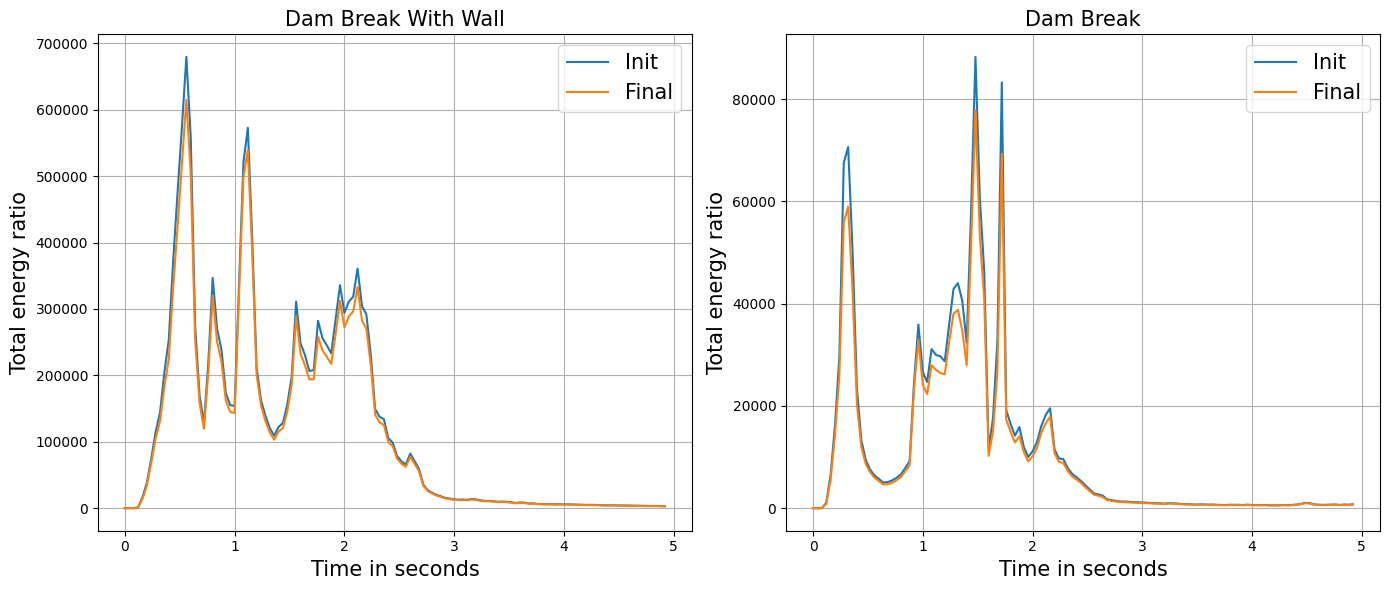

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 
fin = total_final_diss_ramp['vrvisc02_alpha1_particle01']
init = total_diss_ramp['vrvisc02_alpha1_particle01']

time = [i / 25 for i in range(end - begin)]

ax1.plot(time, init, label="Init")
ax1.plot(time, fin, label="Final")

ax1.legend(fontsize=15)
ax1.grid(True)
ax1.set_title("Dam Break With Wall", fontsize=15)
ax1.set_xlabel("Time in seconds", fontsize=15)
ax1.set_ylabel("Total energy ratio", fontsize=15)


fin = total_final_diss_basicadam['no cfl 0.001 alpha 1.2']
init = total_diss_basicadam['no cfl 0.001 alpha 1.2']

time = [i / 25 for i in range(end - begin)]

ax2.plot(time, init, label="Init")
ax2.plot(time, fin, label="Final")

ax2.legend(fontsize=15)
ax2.grid(True)
ax2.set_title("Dam Break", fontsize=15)
ax2.set_xlabel("Time in seconds", fontsize=15)
ax2.set_ylabel("Total energy ratio", fontsize=15)


plt.tight_layout()
plt.savefig('cylinder_ramp.png', dpi=300, bbox_inches="tight")
plt.show()


## Ramp Other Advection Projection

In [53]:
scene = 'Ramp'

folder_path = splishsplash_path_e + scene + '/'

print(folder_path)

folders = os.listdir(folder_path)

print(folders)

E:/gabi/thesis/Ramp/
['visc02both_particle01_alpha0_cfl001', 'visc02both_particle01_alpha13_cfl001', 'pcisph', 'iisph', 'iisph_baseline', 'pcisph_baseline']


In [56]:
begin = 1
end = 110
time = [i / 25 for i in range(end - begin)]

total_energy_cylinder = {}
enstrophy_dict_cylinder = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    ls_total_energy = []
    enstrophy = []
    for i in range(begin,end):
        if i == 73: 
            continue
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            ls_total_energy.append((aux_kin_energy + aux_pot_energy))
#             ls_total_energy.append((aux_kin_energy))
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
#         else:
#             ls_total_energy.append(0)
    enstrophy_dict_cylinder[folder] = enstrophy
    total_energy_cylinder[folder] = ls_total_energy
#     ax1.plot(time, ls_total_energy, label="{}".format(folder))


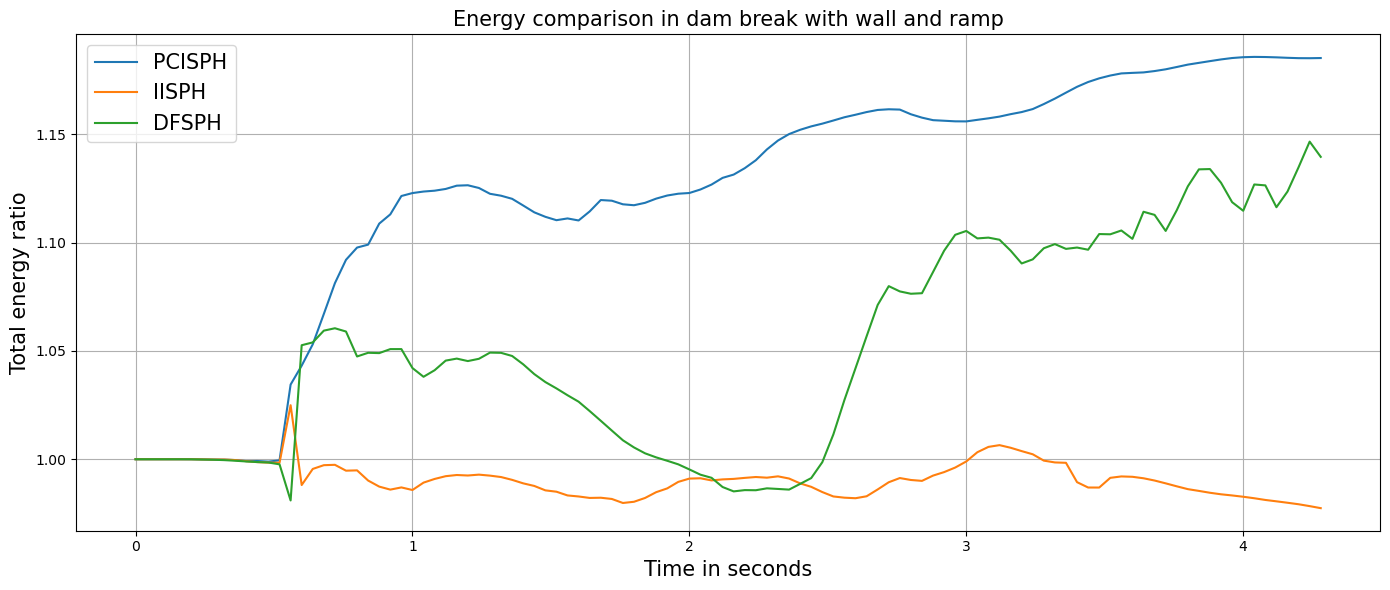

In [60]:
fig, axes = plt.subplots(1, 1, figsize=(14, 6)) 
ax1 = axes 
begin = 1
end = 109
time = [i / 25 for i in range(end - begin)]


ax1.plot(time, [x / y for x, y in zip(total_energy_cylinder['pcisph'], total_energy_cylinder['pcisph_baseline'])], label="PCISPH")
ax1.plot(time, [x / y for x, y in zip(total_energy_cylinder['iisph'], total_energy_cylinder['iisph_baseline'])], label="IISPH")
ax1.plot(time, [x / y for x, y in zip(total_energy_cylinder['visc02both_particle01_alpha13_cfl001'], total_energy_cylinder['visc02both_particle01_alpha0_cfl001'])], label="DFSPH")
ax1.legend(fontsize=15)
ax1.grid(True)
ax1.set_title("Energy comparison in dam break with wall and ramp", fontsize=15)
ax1.set_xlabel("Time in seconds", fontsize=15)
ax1.set_ylabel("Total energy ratio", fontsize=15)

plt.tight_layout()
plt.savefig('pcisph_iisph_dfsph.png', dpi=300, bbox_inches="tight")
plt.show()


## Kelvin Helmholtz

In [3]:
scene = 'KelvinHelmholtz3D'

folder_path = splishsplash_path_e + scene + '/'

print(folder_path)

folders = os.listdir(folder_path)
# folders.remove('baseline_firsttry')
# folders.remove('baseline_faster')
# folders = ['alpha1.3']
# folders = ['alpha1.0_KevinHelholtz3D_fina', 'alpha0.0_KevinHemholtz3D_fina_baseline', '0.1_KevinHelmholtz3D_fina_vc', '0.4_KevinHelmholtz3D_fina_micropolar_stronger']
# folders = ['0.4_KevinHelmholtz3D_fina_micropolar_stronger']

folders_w_title = {}
folders_w_title['alpha0.0_KevinHemholtz3D_fina_baseline'] = 'No Method'
folders_w_title['alpha1.0_KevinHelholtz3D_fina'] = 'VR - 1.0'
# folders_w_title['0.1_KevinHelmholtz3D_fina_vc'] = 'VC - 0.1'
folders_w_title['1.0_KevinHelmholtz3D_fina_vc_stronger'] = 'VC - 1.0'
folders_w_title['0.4_KevinHelmholtz3D_fina_micropolar_stronger'] = 'Micropolar - 0.4'

print(folders_w_title)
print(folders)

E:/gabi/thesis/KelvinHelmholtz3D/
{'alpha0.0_KevinHemholtz3D_fina_baseline': 'No Method', 'alpha1.0_KevinHelholtz3D_fina': 'VR - 1.0', '1.0_KevinHelmholtz3D_fina_vc_stronger': 'VC - 1.0', '0.4_KevinHelmholtz3D_fina_micropolar_stronger': 'Micropolar - 0.4'}
['alpha1.0_KevinHemholtz3D', 'alpha1.3_KevinHemholtz3D_morealpha', 'alpha1.0_KevinHemholtz3D_morevisc', 'alpha1.0_KevinHelholtz3D_fina', 'alpha1.5_KevinHelmholtz3D_fina_morealpha', 'alpha1.0_KevinHelmholtz3D_fina_morevisc', 'alpha0.0_KevinHemholtz3D_fina_baseline', '0.1_KevinHelmholtz3D_fina_micropolar', '0.1_KevinHelmholtz3D_fina_vc', '0.4_KevinHelmholtz3D_fina_micropolar_stronger', '1.0_KevinHelmholtz3D_fina_vc_stronger']


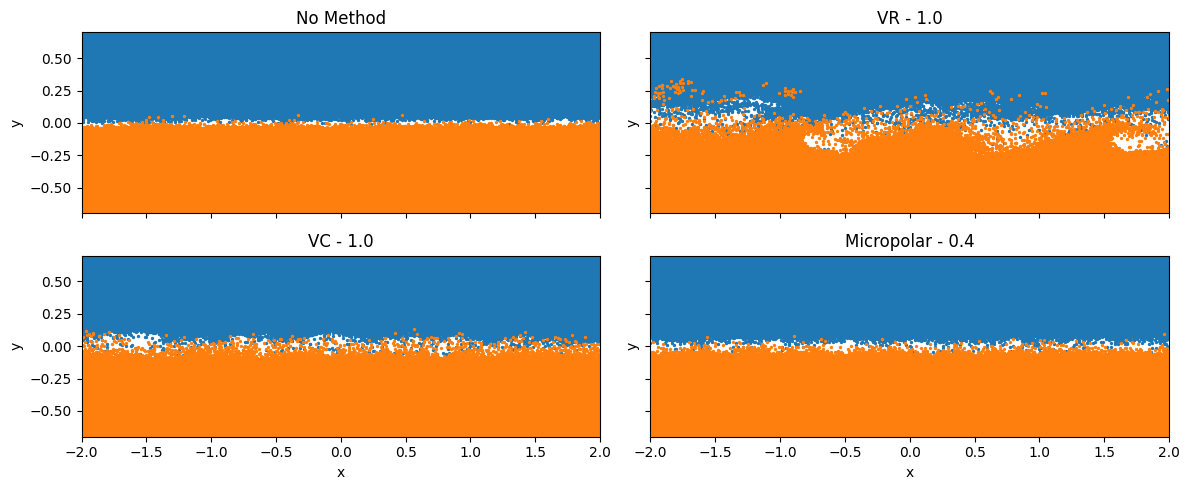

In [8]:
import math

frame = 25
dz = 0.07 
file_templates = [ "ParticleData_Fluid1_{}.vtk", "ParticleData_Fluid2_{}.vtk", ]


ncols = 2
nplots = len(folders_w_title)
nrows = math.ceil(nplots / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(6 * ncols, 2.5 * nrows),
    sharex=True,
    sharey=True,
)

axes = axes.flatten()

for ax, folder in zip(axes, folders_w_title.keys()):

    full_path = folder_path + folder + '/'
    mesh_1 = meshio.read(full_path + file_templates[0].format(frame))
    mesh_2 = meshio.read(full_path + file_templates[1].format(frame))

    pos1 = mesh_1.points
    pos2 = mesh_2.points

    mask1 = np.abs(pos1[:, 2]) < dz
    mask2 = np.abs(pos2[:, 2]) < dz

    slice1 = pos1[mask1]
    slice2 = pos2[mask2]

    ax.scatter(slice1[:, 0], slice1[:, 1], s=2, c='tab:blue')
    ax.scatter(slice2[:, 0], slice2[:, 1], s=2, c='tab:orange')

    ax.set_title(folders_w_title[folder])
    ax.set_ylabel("y")

# Remove unused axes
for ax in axes[nplots:]:
    ax.remove()

# Set limits ONCE (shared by all axes)
axes[0].set_xlim(-2, 2)
axes[0].set_ylim(-0.7, 0.7)

# Label only bottom row
for ax in axes[-ncols:]:
    ax.set_xlabel("x")

plt.tight_layout()
plt.show()


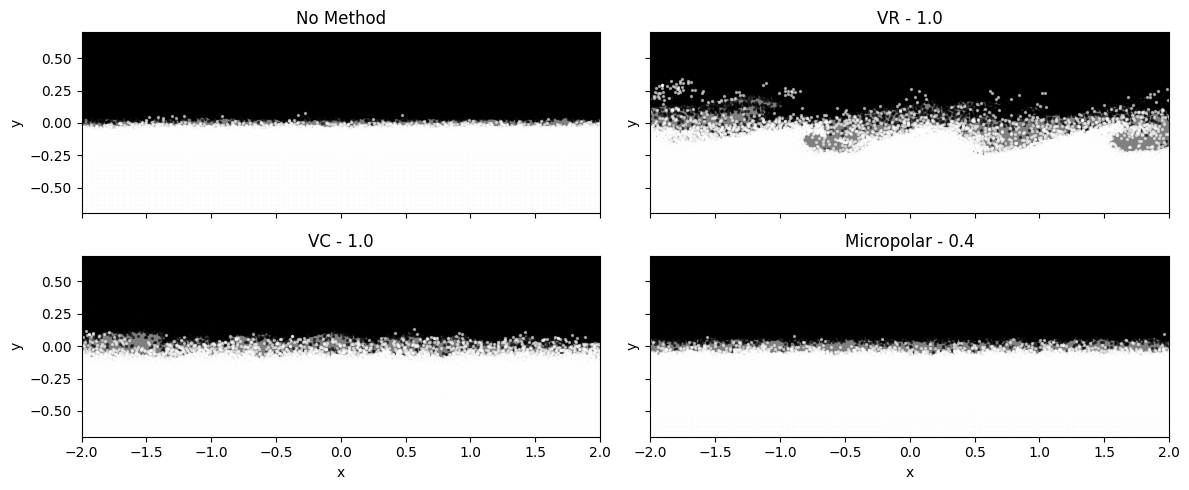

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import meshio
import math

frame = 25
dz = 0.09
file_templates = [ "ParticleData_Fluid1_{}.vtk", "ParticleData_Fluid2_{}.vtk", ]

ncols = 2
nplots = len(folders_w_title)
nrows = math.ceil(nplots / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(6 * ncols, 2.5 * nrows),
    sharex=True,
    sharey=True,
)

axes = axes.flatten()

xlim = (-2, 2)
ylim = (-0.7, 0.7)

for ax, folder in zip(axes, folders_w_title.keys()):
    full_path = folder_path + folder + '/'
    
    # Load fluids
    mesh_1 = meshio.read(full_path + file_templates[0].format(frame))
    mesh_2 = meshio.read(full_path + file_templates[1].format(frame))

    pos1 = mesh_1.points
    pos2 = mesh_2.points

    mask1 = np.abs(pos1[:, 2]) < dz
    mask2 = np.abs(pos2[:, 2]) < dz

    slice1 = pos1[mask1]
    slice2 = pos2[mask2]

    # Plot fluid 1 in black with alpha
    ax.scatter(slice1[:, 0], slice1[:, 1], s=2, c='black', alpha=0.5)
    # Plot fluid 2 in white with alpha
    ax.scatter(slice2[:, 0], slice2[:, 1], s=2, c='white', alpha=0.5)

    ax.set_title(folders_w_title[folder])
    ax.set_ylabel("y")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_facecolor('gray')  # Background gray shows overlap

# Remove unused axes
for ax in axes[nplots:]:
    ax.remove()

# Label only bottom row
for ax in axes[-ncols:]:
    ax.set_xlabel("x")

plt.tight_layout()
plt.savefig('kevinhelmholtz3d.png', dpi=300, bbox_inches="tight")
plt.show()


## Dam Break 2D

In [28]:
scene = 'DamBreakModel_2D'
folder_path = local_path + scene + '/'
print(folder_path)

folders = os.listdir(folder_path)
folders.remove('log')
folders.remove('visc001')
folders.remove('VR0-2.2seconds.png')
folders.remove('VR0-20seconds.png')
folders.remove('VR1-2.2seconds.png')
folders.remove('VR1-20seconds.png')
folders.remove('vtk')
folders.remove('VR0-2.2seconds_part01.png')
folders.remove('VR1-2.2seconds_part01.png')
folders.remove('VR1-20seconds_part01.png')
folders.remove('VR0')
folders.remove('VR1')

print(folders)


C:/Users/gabri/Documents/thesis/SPlisHSPlasH/output/DamBreakModel_2D/
['VR0_part01', 'VR1_part01']


In [29]:
begin = 1
end = 501
time = [i / 25 for i in range(end - begin)]

total_energy_cylinder = {}
enstrophy_dict_cylinder = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    ls_total_energy = []
    enstrophy = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.02 * 0.02 * 0.02

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            ls_total_energy.append((aux_kin_energy + aux_pot_energy))
            # ls_total_energy.append((aux_kin_energy))
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
#         else:
#             ls_total_energy.append(0)
    enstrophy_dict_cylinder[folder] = enstrophy
    total_energy_cylinder[folder] = ls_total_energy
#     ax1.plot(time, ls_total_energy, label="{}".format(folder))


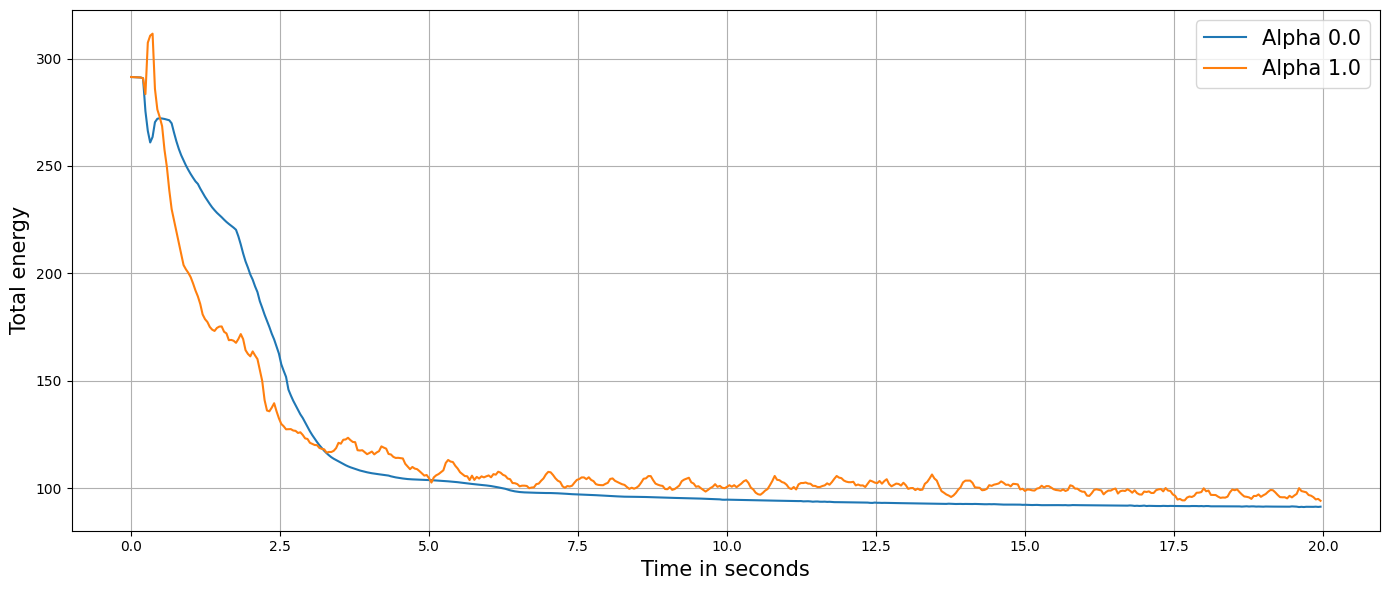

In [33]:
fig, axes = plt.subplots(1, 1, figsize=(14, 6)) 
ax1 = axes 
begin = 1
end = 501
time = [i / 25 for i in range(end - begin)]


ax1.plot(time, total_energy_cylinder['VR0_part01'], label="Alpha 0.0")
ax1.plot(time, total_energy_cylinder['VR1_part01'], label="Alpha 1.0")


ax1.legend(fontsize=15)
ax1.grid(True)
# ax1.set_title("Energy comparison in dam break with wall and ramp", fontsize=15)
ax1.set_xlabel("Time in seconds", fontsize=15)
ax1.set_ylabel("Total energy", fontsize=15)

plt.tight_layout()
plt.savefig('dambreak2d_energy.png', dpi=300, bbox_inches="tight")
plt.show()


## Emitter 2D

In [61]:
scene = 'Emitter_2D'
folder_path = local_path + scene + '/'
print(folder_path)

folders = os.listdir(folder_path)
folders.remove('log')
# folders.remove('visc001')
# folders.remove('VR0-2.2seconds.png')
# folders.remove('VR0-20seconds.png')
# folders.remove('VR1-2.2seconds.png')
# folders.remove('VR1-20seconds.png')
folders.remove('vtk')
# folders.remove('VR0-2.2seconds_part01.png')
# folders.remove('VR1-2.2seconds_part01.png')
# folders.remove('VR1-20seconds_part01.png')
# folders.remove('VR0')
folders.remove('VR1')

print(folders)


C:/Users/gabri/Documents/thesis/SPlisHSPlasH/output/Emitter_2D/
['baseline', 'VR02', 'VR04']


In [62]:
begin = 1
end = 251
time = [i / 25 for i in range(end - begin)]

total_energy_cylinder = {}
enstrophy_dict_cylinder = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    ls_total_energy = []
    enstrophy = []
    for i in range(begin,end):

        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        try:
            mesh = meshio.read(full_path + file)
        except Exception:
            ls_total_energy.append(0)
            continue
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.02 * 0.02 * 0.02

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            ls_total_energy.append((aux_kin_energy + aux_pot_energy))
            # ls_total_energy.append((aux_kin_energy))
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
        else:
            ls_total_energy.append(0)
    enstrophy_dict_cylinder[folder] = enstrophy
    total_energy_cylinder[folder] = ls_total_energy
#     ax1.plot(time, ls_total_energy, label="{}".format(folder))


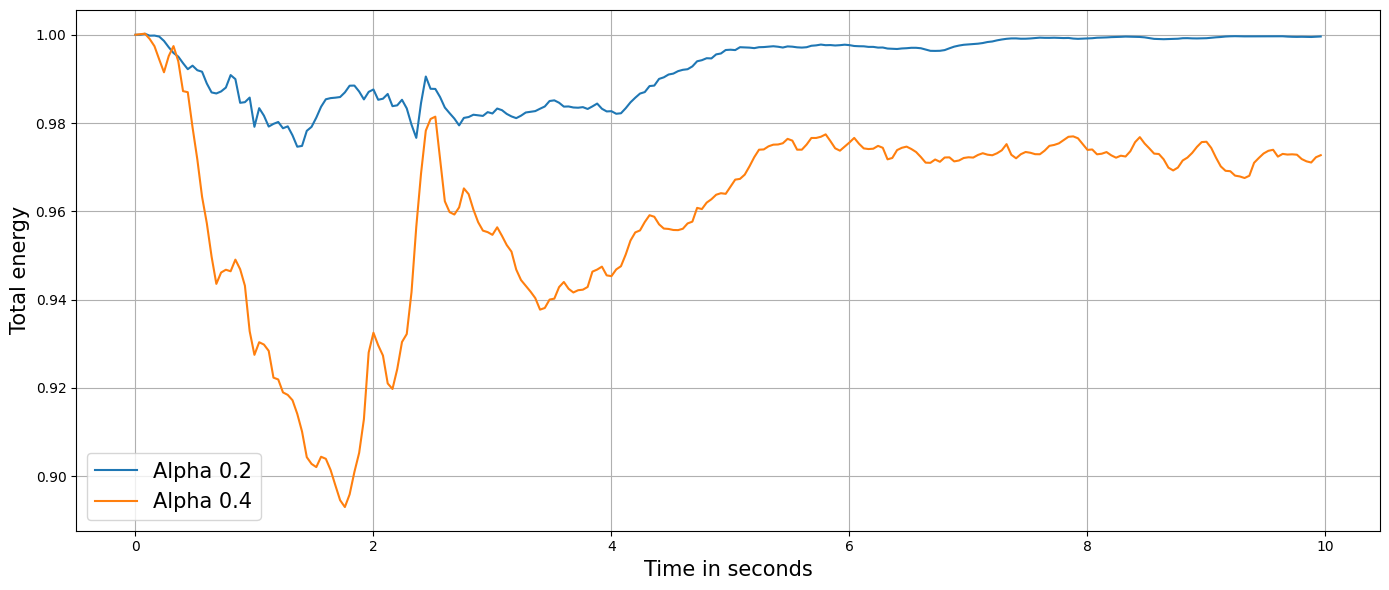

In [64]:
fig, axes = plt.subplots(1, 1, figsize=(14, 6)) 
ax1 = axes 
# begin = 1
# end = 501
# time = [i / 25 for i in range(end - begin)]


# ax1.plot(time,  [x / y for x, y in zip(total_energy_cylinder['VR1'], total_energy_cylinder['baseline'])], label="Alpha 0.0")
ax1.plot(time,  [x / y for x, y in zip(total_energy_cylinder['VR02'], total_energy_cylinder['baseline'])], label="Alpha 0.2")
ax1.plot(time,  [x / y for x, y in zip(total_energy_cylinder['VR04'], total_energy_cylinder['baseline'])], label="Alpha 0.4")
# ax1.plot(time,  [x / y for x, y in zip(total_energy_cylinder['VR06'], total_energy_cylinder['baseline'])], label="Alpha 0.6")
# ax1.plot(time,  [x / y for x, y in zip(total_energy_cylinder['VR08'], total_energy_cylinder['baseline'])], label="Alpha 0.8")


ax1.legend(fontsize=15)
ax1.grid(True)
# ax1.set_title("Energy comparison in dam break with wall and ramp", fontsize=15)
ax1.set_xlabel("Time in seconds", fontsize=15)
ax1.set_ylabel("Total energy", fontsize=15)

plt.tight_layout()
plt.savefig('dambreak2d_energy.png', dpi=300, bbox_inches="tight")
plt.show()


## Energy Cascade

In [76]:
scene = 'Ramp'

folder_path = splishsplash_path_e + scene + '/'

print(folder_path)

folders = os.listdir(folder_path)
# folders.remove('baseline_firsttry')
# folders.remove('baseline_faster')

print(folders)

E:/gabi/thesis/Ramp/
['visc02both_particle01_alpha0_cfl001', 'visc02both_particle01_alpha13_cfl001']


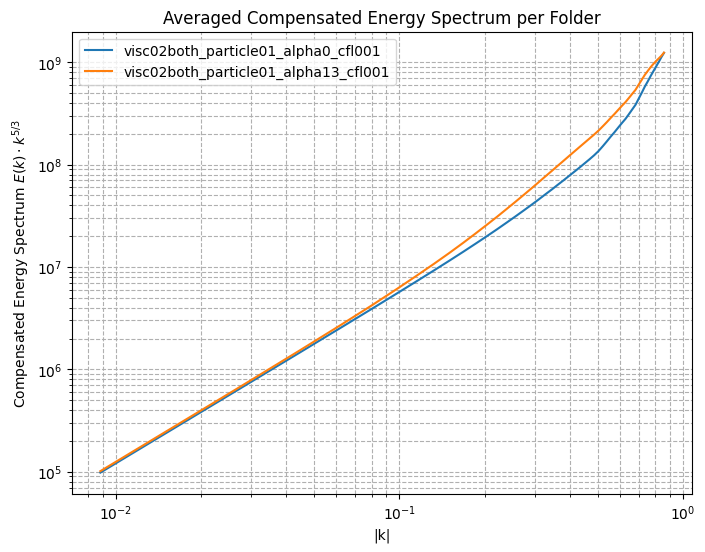

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fftn, fftshift

begin, end = 1, 176  # file indices to process
grid_size = 64       # grid resolution for FFT
k_bins_count = 50    # number of bins for |k|

# Function to bin particle data onto a grid (unchanged)
def grid_particles(positions, velocities, mass, grid_size):
    min_pos = positions.min(axis=0)
    max_pos = positions.max(axis=0)
    norm_pos = (positions - min_pos) / (max_pos - min_pos)
    
    vx_grid = np.zeros((grid_size, grid_size, grid_size))
    vy_grid = np.zeros((grid_size, grid_size, grid_size))
    vz_grid = np.zeros((grid_size, grid_size, grid_size))
    
    idx = (norm_pos * (grid_size-1)).astype(int)
    for i in range(len(positions)):
        x, y, z = idx[i]
        vx_grid[x, y, z] += velocities[i,0] * mass[i]
        vy_grid[x, y, z] += velocities[i,1] * mass[i]
        vz_grid[x, y, z] += velocities[i,2] * mass[i]
    
    return vx_grid, vy_grid, vz_grid

folder_spectra = {}  # store average spectrum per folder

for folder in folders:
    full_path = folder_path + folder + '/'
    spectra_list = []
    
    for i in range(begin, end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)
        mesh = meshio.read(full_path + file)
        
        positions = mesh.points
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05**3
        
        vx_grid, vy_grid, vz_grid = grid_particles(positions, velocity, mass, grid_size)
        
        fx = fftn(vx_grid)
        fy = fftn(vy_grid)
        fz = fftn(vz_grid)
        energy_spectrum_3d = 0.5 * (np.abs(fx)**2 + np.abs(fy)**2 + np.abs(fz)**2)
        energy_spectrum_3d = fftshift(energy_spectrum_3d)
        
        kx = np.fft.fftfreq(grid_size)
        ky = np.fft.fftfreq(grid_size)
        kz = np.fft.fftfreq(grid_size)
        KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')
        k_mag = np.sqrt(KX**2 + KY**2 + KZ**2)
        
        # Avoid zero to prevent divide by zero in compensation
        k_min = 1e-6
        k_bins = np.linspace(k_min, k_mag.max(), k_bins_count)
        
        energy_vs_k = np.zeros(len(k_bins)-1)
        counts = np.zeros(len(k_bins)-1)  # count how many modes per bin
        
        for j in range(len(k_bins)-1):
            mask = (k_mag >= k_bins[j]) & (k_mag < k_bins[j+1])
            energy_vs_k[j] = energy_spectrum_3d[mask].sum()
            counts[j] = np.count_nonzero(mask)
        
        # Normalize by number of modes in each bin to get average energy density
        nonzero = counts > 0
        energy_vs_k[nonzero] /= counts[nonzero]
        
        # Compensate spectrum by k^(5/3) at bin centers
        k_bin_centers = 0.5 * (k_bins[:-1] + k_bins[1:])
        compensated_spectrum = np.zeros_like(energy_vs_k)
        compensated_spectrum[nonzero] = energy_vs_k[nonzero] * (k_bin_centers[nonzero] ** (5/3))
        
        spectra_list.append(compensated_spectrum)
    
    spectra_array = np.array(spectra_list)
    avg_spectrum = spectra_array.mean(axis=0)
    folder_spectra[folder] = (k_bin_centers, avg_spectrum)

# Plotting
plt.figure(figsize=(8,6))
for folder, (k_centers, spectrum) in folder_spectra.items():
    plt.loglog(k_centers, spectrum, label=folder)

plt.xlabel('|k|')
plt.ylabel('Compensated Energy Spectrum $E(k) \cdot k^{5/3}$')
plt.title('Averaged Compensated Energy Spectrum per Folder')
plt.legend()
plt.grid(True, which='both', ls='--')
plt.show()
